# PI-HGAT NZEB Retrofit Pipeline — ICAE 2026

**Integrated decision-support framework for hot-humid NZEB office retrofits, Ho Chi Minh City.**
Case study: DOE Medium Office prototype (4,982 m2), baseline EUI 122.1 kWh/m2/yr, Koppen Aw.

This notebook is the single end-to-end runner; it mirrors the framework figure
(`results/figures/0. FRAMEWORK DEMO.png`) part by part:

| Framework block | Sections | Key inputs | Outputs |
|---|---|---|---|
| **PART 0 — Data Input (Building/Urban/Graph)** | S1 | `data/registry/neo4j_query_table_data_2026-6-2.json` (BIM/Revit -> Neo4j export) | PyG-ready heterogeneous KG topology; **Fig. 2** |
| **PART 0 — Simulation Results (offline jEPlus)** | S2 | `data/aggregated_LHS_results.csv` (9 CMIP6 scenarios x 250 LHS, built by `scripts/data/aggregate_lhs_results.py`) | X (9 features: P1–P7 incl. SHGC + Climate ΔT), Y = **gross site EUI**; scenario split + `combo_id` |
| **PART 0 — Climate-Change Fingerprint** | S3 | paired design: same 249 combos under all 9 scenarios | **Fig. C1–C3** (EUI shift, paired ΔEUI/ΔT slope, end-use shift) |
| **PART 1 — AI-based Prediction** | S4–S10 | HeteroData graphs + global skip; baselines XGBoost/ANN/LR on same split | trained PI-HGAT (`best_hgat_v2.pt`); benchmark + **external test set** (S8); **Fig. 3, 4, 5, S1**; robustness artifacts `results/step3_*.csv` (multi-seed, LOSO, combo-split, PI ablation, learning curve) |
| **PART 2 — Multi-Objective Optimization** | S11–S14 | surrogate f1 (gross EUI) + `pi_hgat/objectives.py`: single `net_energy()` (PV/BESS enter once), f2 LCC, f3 LCE; 9 **integer level variables** = retrofit catalog | NSGA-III Pareto set; Entropy-TOPSIS (single impl.) + `assess_nze()`; `results/pareto_solutions.csv`; weight sensitivity + climate-aware MOO at ΔT = 0 / +2.03 / +4.47 °C; **Fig. 6–11, C5** |
| **PART 3 — XAI & Recommendations** | S15–S16 | trained model + Pareto optimum | GNNExplainer node/edge importance vs SHAP; spatial explanation map + fidelity/sparsity table; **Fig. 12–14** |

**Notes on conventions (review fixes locked in):** the surrogate predicts **gross site EUI**
= f(P1–P7, ΔT) only — PV (P8) and BESS (P9) are excluded from features *and* target, and enter
exactly once via `objectives.net_energy()` in Part 2. NSGA-III searches integer level indices
of the actual measure catalog, so it can never query the surrogate out-of-distribution.

**Economic/LCA basis (locked 2026-07-02):** 20-yr study period, 8% real discount, elec 0.137 USD/kWh
(EVN before-VAT), grid EF 0.6592 kgCO2e/kWh (MONRE 1726/2024), PV yield 1,420 kWh/kWp/yr.
All constants live in `pi_hgat/config.py`; sourced registry: `data/jEPlus-LHS/ICAE2026_DataRegistry_P1-P9.xlsx`.

In [ ]:
import os, sys, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader as TorchDL
from torch_geometric.loader import DataLoader as PyGDL
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
import xgboost as xgb

from pi_hgat.config import *
from pi_hgat.graph_builder import GraphBuilder
from pi_hgat.synthetic_data import SyntheticDataGenerator
from pi_hgat.models import PI_HGAT, BaselineANN
from pi_hgat.physics_loss import PhysicsLoss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

def seed_all(s=42):
    np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)
seed_all(42)

## PART 0 · Section 1 — Data Input: Knowledge Graph (BIM/Revit -> Neo4j -> PyG)
Loads the heterogeneous KG exported from Neo4j (nodes: Building/Storey/Zone/Surface/System;
edges: containment/adjacency) and extracts the zone topology used by the graph builder.


In [ ]:
import time
section_1_start = time.time()

In [ ]:
from pi_hgat.config import NEO4J_JSON_PATH
from pi_hgat.graph_builder import GraphBuilder
print('Loading KG from Neo4j JSON...')
builder = GraphBuilder(NEO4J_JSON_PATH)
baseline_data = builder.create_heterodata()
print(baseline_data)

n_nodes = sum(baseline_data[nt].num_nodes for nt in baseline_data.node_types)
n_edges = sum(baseline_data[et].num_edges for et in baseline_data.edge_types)
print(f'\nNodes: {n_nodes}, Edges: {n_edges}')
print('Node feature dims:')
for nt in baseline_data.node_types:
    print(f'  {nt}: {baseline_data[nt].x.shape}')

Loading KG from Neo4j JSON...
  Envelope types: {'roof': 3, 'wall': 24, 'window': 12}
HeteroData(
  Zone={ x=[15, 4] },
  Envelope={ x=[39, 11] },
  Material={ x=[3, 3] },
  System={ x=[3, 5] },
  Climate={ x=[9, 6] },
  (Zone, hasEnvelope, Envelope)={ edge_index=[2, 107] },
  (Zone, adjacentTo, Zone)={ edge_index=[2, 60] },
  (Zone, SERVED_BY, System)={ edge_index=[2, 15] },
  (Zone, EXPOSED_TO, Climate)={ edge_index=[2, 135] },
  (Envelope, MADE_OF, Material)={ edge_index=[2, 39] }
)

Nodes: 69, Edges: 356
Node feature dims:
  Zone: torch.Size([15, 4])
  Envelope: torch.Size([39, 11])
  Material: torch.Size([3, 3])
  System: torch.Size([3, 5])
  Climate: torch.Size([9, 6])


> ### 📊 FIGURE SLOT — **Fig. 2 · KG schema & case-study building** *(PART 0)*
> **Content:** (a) DOE Medium Office 3D + HCMC context; (b) hetero-KG schema (node types Zone/Envelope/Material/System/Climate, edge types + count outputted above). Inspired by Fig. 4 (BCGS) of the GAT-BEM 2025 paper.
> **Data:** cell S1 (`baseline_data` node/edge counts). **Style:** `fig_style.py`, node types = categorical slots. **Status:** ⬜ chưa dựng


Saved: results/figures/Fig2_KGSchema.png|.pdf


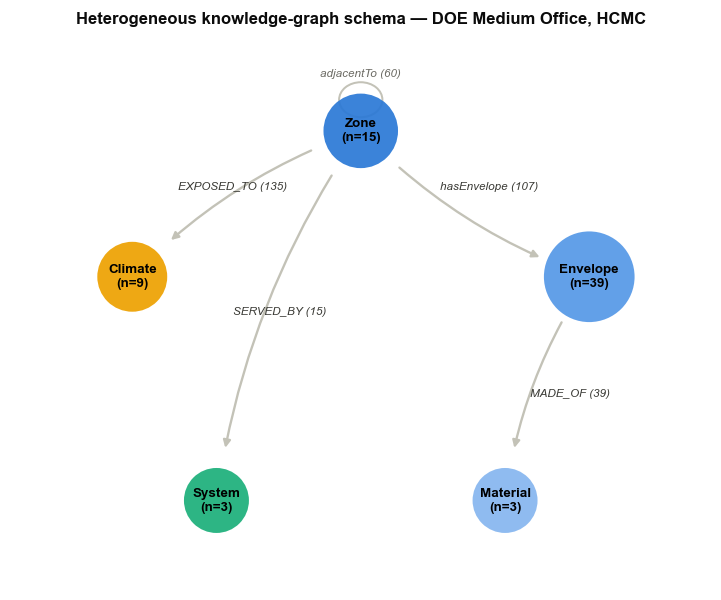

Node counts: {'Zone': 15, 'Envelope': 39, 'Material': 3, 'System': 3, 'Climate': 9} | total edges: 356


In [ ]:
# FIG 2b — heterogeneous KG meta-schema (programmatic). Panel (a) 3D building = external image.
from scripts.analysis.fig_style import apply_style, savefig
import networkx as nx
apply_style()

counts = {nt: baseline_data[nt].num_nodes for nt in baseline_data.node_types}
epos = {'Zone': (0.0, 1.0), 'Envelope': (0.95, 0.25), 'Material': (0.6, -0.9),
        'System': (-0.6, -0.9), 'Climate': (-0.95, 0.25)}
ncol = {'Zone': '#2a78d6', 'Envelope': '#5598e7', 'Material': '#86b6ef',
        'System': '#1baf7a', 'Climate': '#eda100'}

fig, ax = plt.subplots(figsize=(7.5, 6))
G = nx.MultiDiGraph()
for nt in counts:
    G.add_node(nt)
edge_specs = []
for (s, r, t) in baseline_data.edge_types:
    n = baseline_data[(s, r, t)].edge_index.size(1)
    G.add_edge(s, t)
    edge_specs.append((s, t, r, n))

nx.draw_networkx_nodes(G, epos, ax=ax, node_size=[1400 + 40*counts[n] for n in G.nodes],
                       node_color=[ncol[n] for n in G.nodes], alpha=0.92)
nx.draw_networkx_labels(G, epos, ax=ax,
                        labels={n: f'{n}\n(n={counts[n]})' for n in G.nodes},
                        font_size=8, font_family='Arial', font_weight='bold')
for s, t, r, n in edge_specs:
    if s == t:  # Zone adjacentTo Zone self-loop
        ax.annotate(f'{r} ({n})', xy=(epos[s][0], epos[s][1] + 0.28), ha='center',
                    fontsize=7, fontstyle='italic', color='#6b6a63')
        ax.add_patch(plt.Circle((epos[s][0], epos[s][1] + 0.16), 0.09,
                                fill=False, edgecolor='#c3c2b7', lw=1.2))
        continue
    ax.annotate('', xy=epos[t], xytext=epos[s],
                arrowprops=dict(arrowstyle='-|>', color='#c3c2b7', lw=1.4,
                                connectionstyle='arc3,rad=0.12',
                                shrinkA=32, shrinkB=32))
    mx, my = (epos[s][0]+epos[t][0])/2, (epos[s][1]+epos[t][1])/2
    ax.text(mx*1.12, my*1.12, f'{r} ({n})', ha='center', fontsize=7,
            fontstyle='italic', color='#3a3a35')
ax.set_xlim(-1.45, 1.45); ax.set_ylim(-1.35, 1.5); ax.axis('off')
ax.set_title('Heterogeneous knowledge-graph schema — DOE Medium Office, HCMC', fontsize=10, fontweight='bold')
savefig(fig, 'Fig2_KGSchema')
plt.show()
print('Node counts:', counts, '| total edges:', n_edges)

In [ ]:
print(f'\n[Section 1] Execution time: {time.time() - section_1_start:.2f} seconds')


[Section 1] Execution time: 0.71 seconds


## PART 0 · Section 2 — Simulation Results: jEPlus LHS (9 climate scenarios x 250 samples)
Loads `data/aggregated_LHS_results.csv` — REAL EnergyPlus results aggregated from
`data/jEPlus-LHS/{1_Baseline, 2..9}/LHS-*/eplustbl.csv` by `scripts/data/aggregate_lhs_results.py`
(2,250 rows; weather: TMYx 2011-2025 baseline + 8 CMIP6 futures, ACCESS-CM2 / MRI-ESM2-0 x SSP245/585 x 2050s/2080s).

**Target = GROSS site EUI** (`EUI_kWh_m2`, straight from EnergyPlus). P8 PV / P9 BESS are
demand-side-invisible and are **excluded from both X and Y** — they enter f1/f2/f3 only in S11
via the single `objectives.net_energy()` model (review fix B1/B4).
Climate is encoded as the global feature `Climate_DeltaT` (delta-morphing dT per scenario).

⚠ Data note: the same 249 unique parameter combos repeat across all 9 scenarios (paired design).
The scenario-group split below therefore tests **climate transfer** only; the dual-axis
evaluation (GroupKFold by combo + leave-one-scenario-out) is Step-3 work.

In [ ]:
import time
section_2_start = time.time()

In [ ]:
print('Loading LHS samples from aggregated_LHS_results.csv...')
from sklearn.model_selection import GroupShuffleSplit

df_lhs = pd.read_csv(r'data/aggregated_LHS_results.csv')

# Surrogate learns GROSS site EUI = f(P1..P7, climate). PV (P8) / BESS (P9) are
# excluded here by design — they enter only via objectives.net_energy() in S11.
FEATURE_NAMES = ['P1_Wall_U', 'P2_Roof_U', 'P3_Roof_Reflectance', 'P4_Win_U',
                 'P4_Win_SHGC', 'P5_COP', 'P6_Cool_SP', 'P7_LPD', 'Climate_DeltaT']

samples, X, Y, groups = [], [], [], []
for _, row in df_lhs.iterrows():
    s = {
        'P1_Wall_U': 1.0 / row['@@P1_Wall_R@@'],
        'P2_Roof_U': 1.0 / row['@@P2_Roof_R@@'],
        'P3_Roof_Reflectance': 1.0 - row['@@P3_Roof_Abs@@'],
        'P4_Win_U': row['@@P4_U@@'],
        'P4_Win_SHGC': row['@@P4_SHGC@@'],
        'P5_COP': row['@@P5_COP@@'],
        'P6_Cool_SP': row['@@P6_ClgSetp@@'],
        'P7_LPD': row['@@P7_LPD@@'],
        'Climate_DeltaT': row['Climate_DeltaT'],
    }
    samples.append(s)
    X.append([s[k] for k in FEATURE_NAMES])
    Y.append([row['EUI_kWh_m2']])          # GROSS site EUI from EnergyPlus
    groups.append(str(row['Scenario']))

X_flat = np.array(X)
Y_eui = np.array(Y)
groups = np.array(groups)

# combo_id: hash of the 7 E+ parameters — the same 249 combos repeat in all 9
# scenarios; needed for the Step-3 GroupKFold-by-combo evaluation
param_cols = ['@@P1_Wall_R@@', '@@P2_Roof_R@@', '@@P3_Roof_Abs@@', '@@P4_U@@',
              '@@P4_SHGC@@', '@@P5_COP@@', '@@P6_ClgSetp@@', '@@P7_LPD@@']
combo_id = df_lhs[param_cols].round(4).astype(str).agg('|'.join, axis=1).values

print(f'X: {X_flat.shape}, Y: {Y_eui.shape}')
print(f'Gross EUI range: {Y_eui.min():.1f} - {Y_eui.max():.1f} kWh/m2/yr')
print(f'Unique parameter combos: {len(set(combo_id))} (paired across {len(set(groups))} scenarios)')

# Scenario-group split (climate-transfer view; Step 3 adds combo-grouped + LOSO views)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
idx_train, idx_temp = next(gss1.split(X_flat, Y_eui, groups=groups))
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
idx_val, idx_test = next(gss2.split(X_flat[idx_temp], Y_eui[idx_temp], groups=groups[idx_temp]))
idx_val, idx_test = idx_temp[idx_val], idx_temp[idx_test]
print(f'Group split by Scenario: train={sorted(set(groups[idx_train]))}')
print(f'  val={sorted(set(groups[idx_val]))}, test={sorted(set(groups[idx_test]))}')
print(f'Split: {len(idx_train)} train / {len(idx_val)} val / {len(idx_test)} test')

Loading LHS samples from aggregated_LHS_results.csv...
X: (2250, 9), Y: (2250, 1)
Gross EUI range: 95.1 - 150.4 kWh/m2/yr
Unique parameter combos: 249 (paired across 9 scenarios)
Group split by Scenario: train=[np.str_('1_Baseline'), np.str_('3'), np.str_('4'), np.str_('5'), np.str_('7'), np.str_('9')]
  val=[np.str_('8')], test=[np.str_('2'), np.str_('6')]
Split: 1500 train / 250 val / 500 test


In [ ]:
print(f'\n[Section 2] Execution time: {time.time() - section_2_start:.2f} seconds')


[Section 2] Execution time: 0.08 seconds


## PART 0 · Section 3 — Climate-Change Fingerprint (Fig. C1–C3)
The paired LHS design (same 249 combos in all 9 scenarios) enables a **within-combo** climate
sensitivity analysis — a stronger design than independent samples:
- **Fig. C1:** gross-EUI distribution per scenario (ordered by ΔT) — the whole distribution shifts up.
- **Fig. C2:** paired ΔEUI vs ΔT per combo, with the mean cooling-penalty slope (kWh/m²/yr per °C).
- **Fig. C3:** end-use decomposition (baseline vs median future vs worst 2080s) — cooling drives the increase.

In [ ]:
import time
section_3_start = time.time()

Saved: results/figures/FigC1_ClimateEUI.png|.pdf


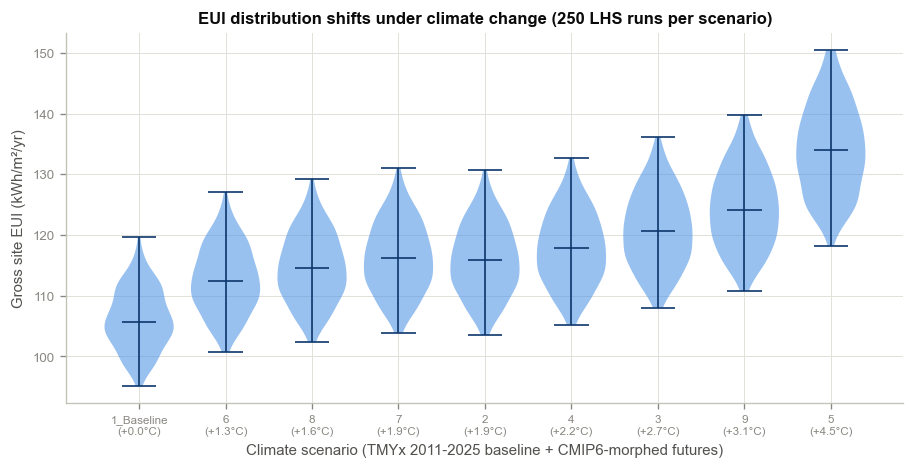

Saved: results/figures/FigC2_PairedSensitivity.png|.pdf


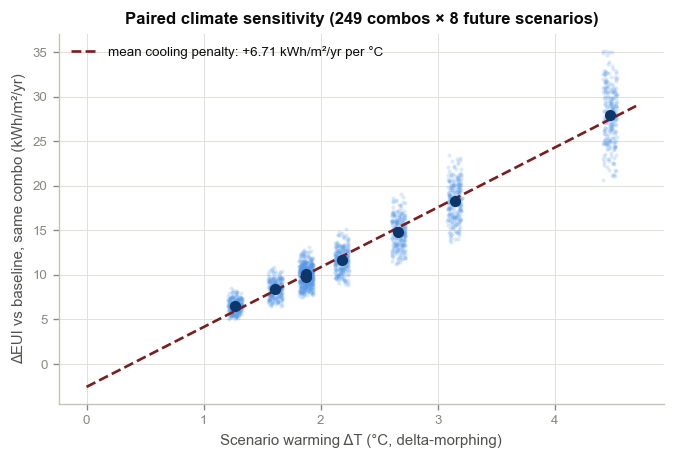

Saved: results/figures/FigC3_EndUseShift.png|.pdf


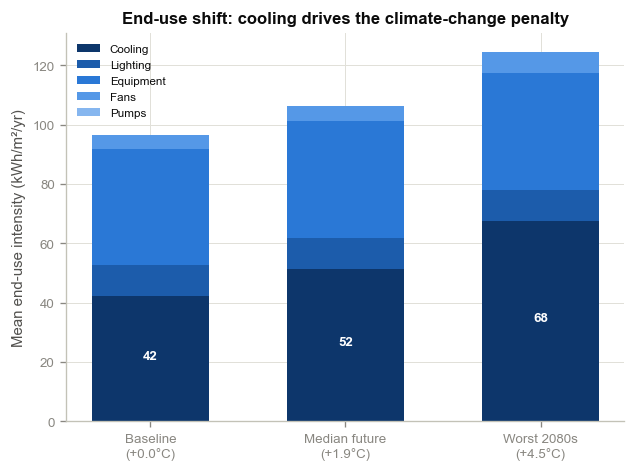

In [ ]:
from networkx.algorithms import link_prediction
# FIGURES C1-C3 — climate-change fingerprint (paired LHS design)
from scripts.analysis.fig_style import apply_style, savefig
apply_style()

d = df_lhs.copy()
d['Scenario'] = d['Scenario'].astype(str)
d['combo'] = combo_id
scen_dt = d.groupby('Scenario')['Climate_DeltaT'].first().sort_values()
scen_order = scen_dt.index.tolist()

# --- FIG C1: EUI distribution per scenario ---
fig, ax = plt.subplots(figsize=(9, 4))
vals = [d.loc[d.Scenario == s, 'EUI_kWh_m2'].values for s in scen_order]
vp = ax.violinplot(vals, showmedians=True, widths=0.8)
for body in vp['bodies']:
    body.set_facecolor('#5598e7'); body.set_alpha(0.6)
for part in ('cmedians', 'cmins', 'cmaxes', 'cbars'):
    vp[part].set_color('#0d366b'); vp[part].set_linewidth(1)
ax.set_xticks(range(1, len(scen_order) + 1))
ax.set_xticklabels([f'{s}\n(+{scen_dt[s]:.1f}°C)' for s in scen_order], fontsize=7)
ax.set_ylabel('Gross site EUI (kWh/m²/yr)')
ax.set_xlabel('Climate scenario (TMYx 2011-2025 baseline + CMIP6-morphed futures)')
ax.set_title('EUI distribution shifts under climate change (250 LHS runs per scenario)')
savefig(fig, 'FigC1_ClimateEUI')
plt.show()

# --- FIG C2: paired climate sensitivity (same combos across scenarios) ---
base = d[d.Scenario == '1_Baseline'].drop_duplicates('combo').set_index('combo')['EUI_kWh_m2']
fig, ax = plt.subplots(figsize=(6.5, 4))
xs, ys = [], []
rng = np.random.RandomState(0)
for s in scen_order:
    if s == '1_Baseline':
        continue
    sub = d[d.Scenario == s]
    delta = (sub['EUI_kWh_m2'] - sub['combo'].map(base)).dropna().values
    x = np.full(len(delta), scen_dt[s])
    ax.scatter(x + rng.uniform(-0.06, 0.06, len(delta)), delta, s=6, alpha=0.2, color='#5598e7')
    ax.scatter([scen_dt[s]], [delta.mean()], s=45, color='#0d366b', zorder=5)
    xs.extend(x); ys.extend(delta)
slope, intercept = np.polyfit(xs, ys, 1)
xr = np.linspace(0, max(xs) * 1.05, 20)
ax.plot(xr, slope * xr + intercept, '--', color='#7a1f1f', lw=1.6,
        label=f'mean cooling penalty: +{slope:.2f} kWh/m²/yr per °C')
ax.set_xlabel('Scenario warming ΔT (°C, delta-morphing)')
ax.set_ylabel('ΔEUI vs baseline, same combo (kWh/m²/yr)')
ax.set_title('Paired climate sensitivity (249 combos × 8 future scenarios)')
ax.legend(prop={'size': 8})
savefig(fig, 'FigC2_PairedSensitivity')
plt.show()

# --- FIG C3: end-use shift ---
eu_cols = {'Cooling': 'Cooling_Elec_GJ', 'Lighting': 'IntLighting_Elec_GJ',
           'Equipment': 'IntEquip_Elec_GJ', 'Fans': 'Fans_Elec_GJ', 'Pumps': 'Pumps_Elec_GJ'}
futures = scen_dt.drop('1_Baseline')
pick = ['1_Baseline', (futures - futures.median()).abs().idxmin(), futures.idxmax()]
labels3 = [f'Baseline\n(+0.0°C)', f'Median future\n(+{scen_dt[pick[1]]:.1f}°C)',
           f'Worst 2080s\n(+{scen_dt[pick[2]]:.1f}°C)']
GJ_TO_KWH_M2 = 1000.0 / 3.6 / 4982.0
colors5 = ['#0d366b', '#1c5cab', '#2a78d6', '#5598e7', '#86b6ef']
fig, ax = plt.subplots(figsize=(6, 4.2))
bottoms = np.zeros(3)
for (name, col), c in zip(eu_cols.items(), colors5):
    v = np.array([d[d.Scenario == s][col].mean() * GJ_TO_KWH_M2 for s in pick])
    ax.bar(labels3, v, bottom=bottoms, label=name, color=c, width=0.6)
    if name == 'Cooling':
        for xi, vi in enumerate(v):
            ax.text(xi, vi / 2, f'{vi:.0f}', ha='center', color='white',
                    fontsize=8, fontweight='bold')
    bottoms += v
ax.set_ylabel('Mean end-use intensity (kWh/m²/yr)')
ax.set_title('End-use shift: cooling drives the climate-change penalty')
ax.legend(prop={'size': 7}, loc='upper left')
savefig(fig, 'FigC3_EndUseShift')
plt.show()

In [ ]:
print(f'\n[Section 3] Execution time: {time.time() - section_3_start:.2f} seconds')


[Section 3] Execution time: 1.29 seconds


## PART 1 · Section 4 — Build PyG HeteroData Dataset
One heterogeneous graph per LHS sample: type-specific node features (zone geometry, envelope
parameters, system efficiencies) + global retrofit vector. Train/val/test = 70/15/15.


In [ ]:
import time
section_4_start = time.time()

In [ ]:
print(f'Building {len(samples)} HeteroData graphs with type-specific features...')
t0 = time.time()
dataset = []
for i, s in enumerate(samples):
    data = builder.create_sample_graph(s)
    data.y = torch.tensor([[Y_eui[i, 0]]], dtype=torch.float)
    # Store flat params for global skip connection (9 features: P1-P7 + DeltaT)
    data.global_params = torch.from_numpy(X_flat[i]).float().unsqueeze(0)
    dataset.append(data)
    if (i+1) % 1000 == 0:
        print(f'  {i+1}/{len(samples)} ...')

train_loader = PyGDL([dataset[i] for i in idx_train], batch_size=TRAIN_PARAMS['batch_size'], shuffle=True)
val_loader   = PyGDL([dataset[i] for i in idx_val],   batch_size=TRAIN_PARAMS['batch_size'])
test_loader  = PyGDL([dataset[i] for i in idx_test],  batch_size=TRAIN_PARAMS['batch_size'])
print(f'DataLoaders ready ({time.time()-t0:.1f}s)')

Building 2250 HeteroData graphs with type-specific features...
  1000/2250 ...
  2000/2250 ...
DataLoaders ready (0.4s)


In [ ]:
print(f'\n[Section 4] Execution time: {time.time() - section_4_start:.2f} seconds')


[Section 4] Execution time: 0.41 seconds


## PART 1 · Section 5 — Define & Initialize PI-HGAT
Heterogeneous Graph Attention Network with physics-informed loss (`pi_hgat/models.py`,
`pi_hgat/physics_loss.py`).


In [ ]:
import time
section_5_start = time.time()

In [ ]:
metadata = baseline_data.metadata()
print('Edge types:', [f'{s}-[{r}]->{t}' for s,r,t in metadata[1]])

model = PI_HGAT(
    metadata=metadata,
    hidden_channels=GNN_PARAMS['hidden_channels'],
    out_channels=1,
    num_layers=GNN_PARAMS['num_layers'],
    heads=GNN_PARAMS['heads'],
    dropout=GNN_PARAMS['dropout'],
    global_dim=len(FEATURE_NAMES),   # 9: P1-P7 (8 values) + Climate_DeltaT
).to(device)

# Init lazy modules with dummy forward
dummy = next(iter(train_loader)).to(device)
model(dummy.x_dict, dummy.edge_index_dict, dummy.batch_dict, dummy.global_params)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nModel parameters: {n_params:,}')

Edge types: ['Zone-[hasEnvelope]->Envelope', 'Zone-[adjacentTo]->Zone', 'Zone-[SERVED_BY]->System', 'Zone-[EXPOSED_TO]->Climate', 'Envelope-[MADE_OF]->Material']

Model parameters: 43,329


In [ ]:
print(f'\n[Section 5] Execution time: {time.time() - section_5_start:.2f} seconds')


[Section 5] Execution time: 0.27 seconds


## PART 1 · Section 6 — Train PI-HGAT (Adam + LR scheduler + early stopping)


In [ ]:
import time
section_6_start = time.time()

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=TRAIN_PARAMS['lr'],
                             weight_decay=TRAIN_PARAMS['weight_decay'])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=TRAIN_PARAMS['epochs'], eta_min=1e-6)
criterion = PhysicsLoss(lambda_bound=0.1, lambda_mono=0.0)

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total = 0.
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for batch in loader:
            batch = batch.to(device)
            out = model(batch.x_dict, batch.edge_index_dict,
                        batch.batch_dict, batch.global_params)
            loss, _, _, _ = criterion(out, batch.y)
            if is_train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total += loss.item() * batch.num_graphs
    return total / len(loader.dataset)

hist = {'train': [], 'val': []}
best_val, patience_cnt = 1e9, 0
print('Training PI-HGAT...')
t0 = time.time()

for ep in range(1, TRAIN_PARAMS['epochs']+1):
    tl = run_epoch(model, train_loader, optimizer)
    vl = run_epoch(model, val_loader)
    scheduler.step()   # review fix M5: CosineAnnealing steps by epoch, NOT by val loss
    hist['train'].append(tl); hist['val'].append(vl)

    if vl < best_val:
        best_val = vl; patience_cnt = 0
        torch.save(model.state_dict(), 'best_hgat_v2.pt')
    else:
        patience_cnt += 1
        if patience_cnt >= TRAIN_PARAMS['patience']:
            print(f'Early stop @ epoch {ep}'); break

    if ep % 20 == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f'  Ep {ep:3d}: train={tl:.2f}  val={vl:.2f}  lr={lr:.1e}')

print(f'Done in {time.time()-t0:.1f}s (best val={best_val:.4f})')
model.load_state_dict(torch.load('best_hgat_v2.pt', weights_only=True))

Training PI-HGAT...
  Ep  20: train=26.35  val=11.52  lr=4.9e-04
  Ep  40: train=19.05  val=6.96  lr=4.8e-04
  Ep  60: train=14.81  val=11.72  lr=4.5e-04
  Ep  80: train=16.40  val=3.29  lr=4.2e-04
  Ep 100: train=15.72  val=1.83  lr=3.8e-04
  Ep 120: train=14.34  val=9.43  lr=3.3e-04
  Ep 140: train=14.61  val=3.01  lr=2.8e-04
  Ep 160: train=12.79  val=1.96  lr=2.2e-04
  Ep 180: train=13.70  val=3.07  lr=1.7e-04
Early stop @ epoch 196
Done in 122.1s (best val=0.7179)


<All keys matched successfully>

In [ ]:
print(f'\n[Section 6] Execution time: {time.time() - section_6_start:.2f} seconds')


[Section 6] Execution time: 122.13 seconds


## PART 1 · Section 7 — Baseline Surrogates (XGBoost, ANN/MLP, Linear Regression)
Same X/Y splits as PI-HGAT for a fair benchmark.


In [ ]:
import time
section_7_start = time.time()

In [ ]:
from sklearn.preprocessing import StandardScaler

Xtr, Ytr = X_flat[idx_train], Y_eui[idx_train].ravel()
Xv, Yv   = X_flat[idx_val],   Y_eui[idx_val].ravel()
Xte, Yte = X_flat[idx_test],  Y_eui[idx_test].ravel()

scaler = StandardScaler()
Xtr_s = scaler.fit_transform(Xtr)
Xv_s  = scaler.transform(Xv)
Xte_s = scaler.transform(Xte)
print('Features standardized (NORM_STATS computed).')

# 1. Linear Regression
print('Training Linear Regression...')
lr_model = LinearRegression().fit(Xtr_s, Ytr)

# 2. XGBoost
print('Training XGBoost...')
xgb_model = xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1,
                              random_state=42, tree_method='exact')
xgb_model.fit(Xtr_s, Ytr)

# 3. ANN
print('Training ANN...')
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader as TorchDL
import copy

ann = BaselineANN(Xtr_s.shape[1], 1).to(device)
ann_opt = torch.optim.Adam(ann.parameters(), lr=1e-3, weight_decay=1e-5)
ann_crit = nn.MSELoss()
ds = TensorDataset(torch.tensor(Xtr_s, dtype=torch.float),
                    torch.tensor(Ytr, dtype=torch.float).unsqueeze(1))
dl = TorchDL(ds, batch_size=64, shuffle=True)

best_ann_loss = 1e9
patience = 20
patience_counter = 0
best_ann_state = None

for ep in range(300):
    ann.train()
    for bx, by in dl:
        bx, by = bx.to(device), by.to(device)
        ann_opt.zero_grad()
        ann_crit(ann(bx), by).backward()
        ann_opt.step()
        
    ann.eval()
    with torch.no_grad():
        val_loss = ann_crit(ann(torch.tensor(Xv_s, dtype=torch.float).to(device)), 
                            torch.tensor(Yv, dtype=torch.float).unsqueeze(1).to(device)).item()
        if val_loss < best_ann_loss:
            best_ann_loss = val_loss
            best_ann_state = copy.deepcopy(ann.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
if best_ann_state is not None:
    ann.load_state_dict(best_ann_state)

print('All baselines trained.')

Features standardized (NORM_STATS computed).
Training Linear Regression...
Training XGBoost...
Training ANN...
All baselines trained.


In [ ]:
print(f'\n[Section 7] Execution time: {time.time() - section_7_start:.2f} seconds')


[Section 7] Execution time: 8.45 seconds


## PART 1 · Section 8 — Evaluation & Benchmark (R2, RMSE, MAE)
Produces the surrogate comparison table (paper Table: model benchmark).


In [ ]:
import time
section_8_start = time.time()

In [ ]:
def metrics(yt, yp):
    return dict(R2=r2_score(yt, yp),
                RMSE=mean_squared_error(yt, yp)**0.5,
                MAE=mean_absolute_error(yt, yp),
                MAPE=mean_absolute_percentage_error(yt, yp)*100)

# PI-HGAT
model.eval()
hgat_p, hgat_t = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch.x_dict, batch.edge_index_dict,
                    batch.batch_dict, batch.global_params)
        hgat_p.extend(out.cpu().numpy().flatten())
        hgat_t.extend(batch.y.cpu().numpy().flatten())
hgat_p, hgat_t = np.array(hgat_p), np.array(hgat_t)

# Baselines (using standardized features)
lr_p  = lr_model.predict(Xte_s)
xgb_p = xgb_model.predict(Xte_s)
ann.eval()
with torch.no_grad():
    ann_p = ann(torch.tensor(Xte_s, dtype=torch.float).to(device)).cpu().numpy().flatten()

results = {
    'PI-HGAT':    metrics(hgat_t, hgat_p),
    'XGBoost':    metrics(Yte, xgb_p),
    'ANN (MLP)':  metrics(Yte, ann_p),
    'Linear Reg': metrics(Yte, lr_p),
}
# df_results (NOT df — keep the LHS dataframe intact; review minor fix)
df_results = pd.DataFrame(results).T
df_results.columns = ['R²', 'RMSE', 'MAE', 'MAPE (%)']
print('\n===== BENCHMARK RESULTS (target = GROSS site EUI) =====')
display(df_results.round(4))


===== BENCHMARK RESULTS (target = GROSS site EUI) =====


,R²,RMSE,MAE,MAPE (%)
PI-HGAT,0.9788,0.8515,0.6884,0.6009
XGBoost,0.8097,2.5509,1.9424,1.7176
ANN (MLP),0.9744,0.9363,0.7482,0.6601
Linear Reg,0.9695,1.0207,0.8689,0.7604


In [1]:
# --- EXTERNAL TEST SET (new LHS seed 2810, never seen in training or model selection) ---
# Review fix: previous version imported a non-existent module (scripts.models.build_graphs)
# and re-instantiated the model with a wrong constructor. This version reuses the SAME
# graph-building convention as S2/S4 and the in-memory trained `model` (best weights
# already restored at the end of S6), so external metrics are directly comparable.
print('Evaluating on External Test Set (seed 2810) ---')
ext_df = pd.read_csv('data/external_test_results.csv')
ext_df = ext_df[ext_df['Message'].str.contains('Completed Successfully', na=False)].reset_index(drop=True)
print(f'Loaded {len(ext_df)} external test samples '
      f'({ext_df["Scenario"].nunique()} scenarios: {sorted(ext_df["Scenario"].unique())})')

ext_dataset, ext_X, ext_scen = [], [], []
for _, row in ext_df.iterrows():
    s = {
        'P1_Wall_U': 1.0 / row['@@P1_Wall_R@@'],
        'P2_Roof_U': 1.0 / row['@@P2_Roof_R@@'],
        'P3_Roof_Reflectance': 1.0 - row['@@P3_Roof_Abs@@'],
        'P4_Win_U': row['@@P4_U@@'],
        'P4_Win_SHGC': row['@@P4_SHGC@@'],
        'P5_COP': row['@@P5_COP@@'],
        'P6_Cool_SP': row['@@P6_ClgSetp@@'],
        'P7_LPD': row['@@P7_LPD@@'],
        'Climate_DeltaT': row['Climate_DeltaT'],
    }
    x_vec = [s[k] for k in FEATURE_NAMES]
    data = builder.create_sample_graph(s)
    data.y = torch.tensor([[row['EUI_kWh_m2']]], dtype=torch.float)
    data.global_params = torch.tensor([x_vec], dtype=torch.float)
    ext_dataset.append(data); ext_X.append(x_vec); ext_scen.append(str(row['Scenario']))

ext_loader = PyGDL(ext_dataset, batch_size=TRAIN_PARAMS['batch_size'])

model.eval()
ext_p, ext_t = [], []
with torch.no_grad():
    for batch in ext_loader:
        batch = batch.to(device)
        out = model(batch.x_dict, batch.edge_index_dict,
                    batch.batch_dict, batch.global_params)
        ext_p.extend(out.cpu().numpy().flatten())
        ext_t.extend(batch.y.cpu().numpy().flatten())
ext_p, ext_t = np.array(ext_p), np.array(ext_t)

# Baselines on the identical external set (same scaler fitted on train only)
ext_Xs = scaler.transform(np.array(ext_X))
ann.eval()
with torch.no_grad():
    ann_ext = ann(torch.tensor(ext_Xs, dtype=torch.float).to(device)).cpu().numpy().flatten()

ext_results = {
    'PI-HGAT (external)':    metrics(ext_t, ext_p),
    'XGBoost (external)':    metrics(ext_t, xgb_model.predict(ext_Xs)),
    'ANN (MLP) (external)':  metrics(ext_t, ann_ext),
    'Linear Reg (external)': metrics(ext_t, lr_model.predict(ext_Xs)),
}
df_ext = pd.DataFrame(ext_results).T
df_ext.columns = ['R²', 'RMSE', 'MAE', 'MAPE (%)']
df_results = pd.concat([df_results, df_ext])
print('===== BENCHMARK incl. EXTERNAL TEST (target = GROSS site EUI) =====')
display(df_results.round(4))

# Per-scenario external error for the paper's data statement
ext_err = pd.DataFrame({'Scenario': ext_scen, 'abs_err': np.abs(ext_t - ext_p)})
print('PI-HGAT external MAE per scenario (kWh/m2/yr):')
display(ext_err.groupby('Scenario')['abs_err'].agg(['mean', 'max']).round(3))


Evaluating on External Test Set (seed 2810) ---


NameError: name 'pd' is not defined

In [ ]:
print(f'\n[Section 8] Execution time: {time.time() - section_8_start:.2f} seconds')


[Section 8] Execution time: 56.73 seconds


## PART 1 · Section 9 — Visualization: Prediction Performance
Produces **Fig. 3** (actual vs predicted). Save outputs to `results/figures/`.


In [ ]:
import time
section_9_start = time.time()

> ### 📊 FIGURE SLOT — **Fig. 3 · Predicted vs Actual (4 panels)** *(PART 1)*
> 4 panel PI-HGAT ★ / XGBoost / ANN / LR on the test set; identity line + R² annotation; màu theo `MODEL_COLORS`. Thay thế `Fig3_PredictionPerf.png` (mock). **Data:** `hgat_t/hgat_p`, `Yte`, `xgb_p`, `ann_p`, `lr_p`. **Status:** ⬜ pending retraining on real data
>
> ### 📊 FIGURE SLOT — **Fig. 4 · Benchmark & robustness (2×2)** *(PART 1)*
> (a) bars R²/RMSE/MAE/MAPE có value label; (b) boxplot R² qua 10–20 seeds; (c) train-vs-test R² (overfitting check); (d) train time (log s). Gộp Table-6-style của GAT-BEM vào 1 hình. **Cần thêm code:** vòng lặp multi-seed + timing. **Status:** ⬜
>
> ### 📊 FIGURE SLOT — **Fig. 5 · Learning curve — sample-size sufficiency** *(PART 1)*
> CV R² theo n_samples (250 → 2,250, theo scenario-block) + dải ±1σ; chứng minh 250 LHS/climate là đủ (250/62,500 = 0.4% full factorial). **Cần thêm code:** learning-curve loop trên GBR/PI-HGAT. **Status:** ⬜


Saved: results/figures/Fig3_PredictionPerf.png|.pdf


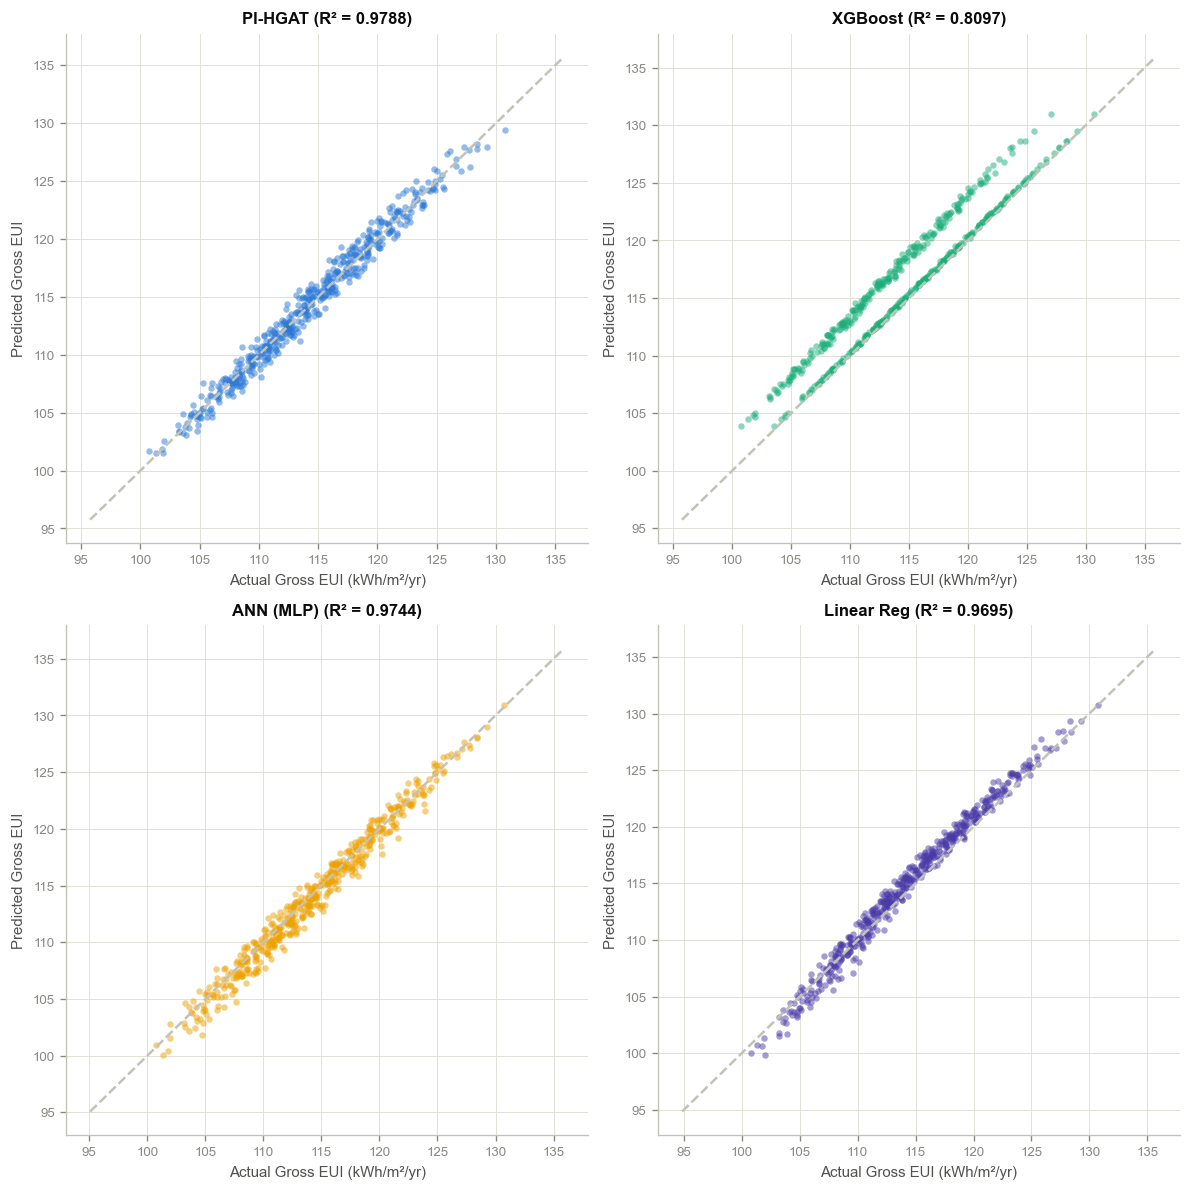

Saved: results/figures/Fig4_BenchmarkBar.png|.pdf


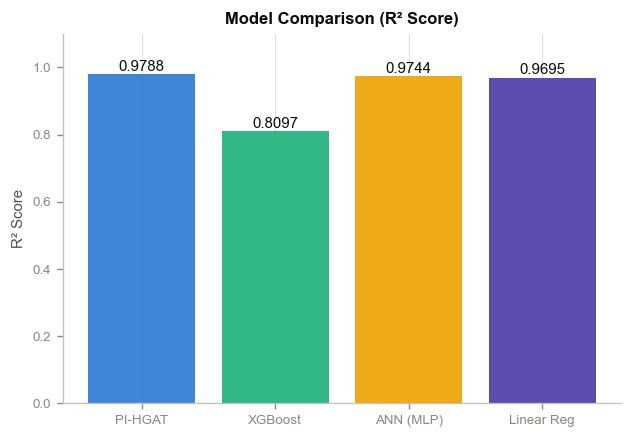

Saved: results/figures/FigS1_TrainingLoss.png|.pdf


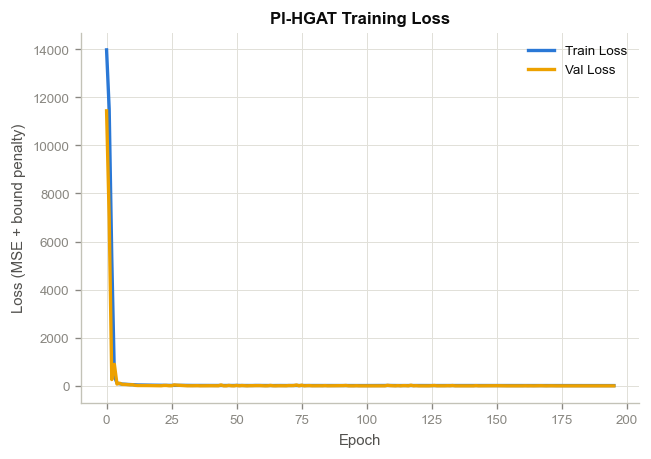

In [ ]:
# FIGURE 5, 6 + supplementary training-loss curve
from scripts.analysis.fig_style import apply_style, savefig, MODEL_COLORS
import matplotlib.pyplot as plt

# Gọi lại apply_style trước mỗi plot để chống Jupyter override
apply_style()

# --- FIG 3: Predicted vs Actual (4-panel) ---
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
targets = [(hgat_t, hgat_p, 'PI-HGAT'), (Yte, xgb_p, 'XGBoost'), 
           (Yte, ann_p, 'ANN (MLP)'), (Yte, lr_p, 'Linear Reg')]

for i, ax in enumerate(axes.flatten()):
    yt, yp, name = targets[i]
    color = MODEL_COLORS.get(name, '#000000')
    ax.scatter(yt, yp, alpha=0.5, s=15, color=color)
    
    lims = [min(yt.min(), yp.min()) - 5, max(yt.max(), yp.max()) + 5]
    ax.plot(lims, lims, '--', lw=1.5, color='#c3c2b7')
    r2 = df_results.loc[name, 'R²']
    ax.set_title(f'{name} (R² = {r2:.4f})', fontname='Arial', fontweight='bold')
    ax.set_xlabel('Actual Gross EUI (kWh/m²/yr)', fontname='Arial')
    ax.set_ylabel('Predicted Gross EUI', fontname='Arial')

plt.tight_layout()
savefig(fig, 'Fig3_PredictionPerf')
plt.show()

# --- FIG 4: Benchmark Bar Chart (R2) — placeholder for the planned 2x2 (multi-seed) panel ---
apply_style()
fig, ax = plt.subplots(figsize=(6, 4))
colors = [MODEL_COLORS[m] for m in df_results.index]
bars = ax.bar(df_results.index, df_results['R²'], color=colors, alpha=0.9)

for bar, val in zip(bars, df_results['R²']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', fontsize=9, fontname='Arial', color='#0b0b0b')

ax.set_title('Model Comparison (R² Score)', fontname='Arial', fontweight='bold')
ax.set_ylabel('R² Score', fontname='Arial')
ax.set_ylim(0, 1.1)
ax.grid(axis='y')
for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontname('Arial')
    
savefig(fig, 'Fig4_BenchmarkBar')
plt.show()

# --- Supplementary: PI-HGAT training loss (per-epoch). NOTE: this is NOT the paper's
# Fig. 5 — FIGURE_PLAN Fig. 5 is the sample-size learning curve (Step-3 work). ---
apply_style()
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(hist['train'], label='Train Loss', color=MODEL_COLORS['PI-HGAT'], lw=2)
ax.plot(hist['val'], label='Val Loss', color='#eda100', lw=2) 
ax.set_title('PI-HGAT Training Loss', fontname='Arial', fontweight='bold')
ax.set_xlabel('Epoch', fontname='Arial')
ax.set_ylabel('Loss (MSE + bound penalty)', fontname='Arial')
for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontname('Arial')
ax.legend(prop={'family': 'Arial', 'size': 8})
savefig(fig, 'FigS1_TrainingLoss')
plt.show()

In [ ]:
print(f'\n[Section 9] Execution time: {time.time() - section_9_start:.2f} seconds')


[Section 9] Execution time: 11.21 seconds


## PART 1 · Section 10 — Robustness & Validation Studies (Fig. 4, Fig. 5, Tables)
Reads artifacts from `scripts/analysis/step3_robustness.py` (run offline:
`python scripts/analysis/step3_robustness.py --study all`, ~50 min GPU):
- **Fig. 4 (2×2):** test R² mean±σ (10 seeds) · seed boxplot · train-vs-test R² (overfitting) · training time — review plan Step 3.
- **Fig. 5:** sample-size learning curve (25→249 combos/scenario, tested on 2 held-out climate scenarios) — evidence for the "is 250 LHS/scenario enough?" question.
- **Tables:** LOSO 9-fold per-scenario MAE (climate generalization, incl. SSP585-2080s ΔT=4.47) · held-out-combo split (parameter generalization) · physics monotonicity-loss ablation.

In [ ]:
import time
section_10_start = time.time()

Saved: results/figures/Fig4_BenchmarkRobustness.png|.pdf


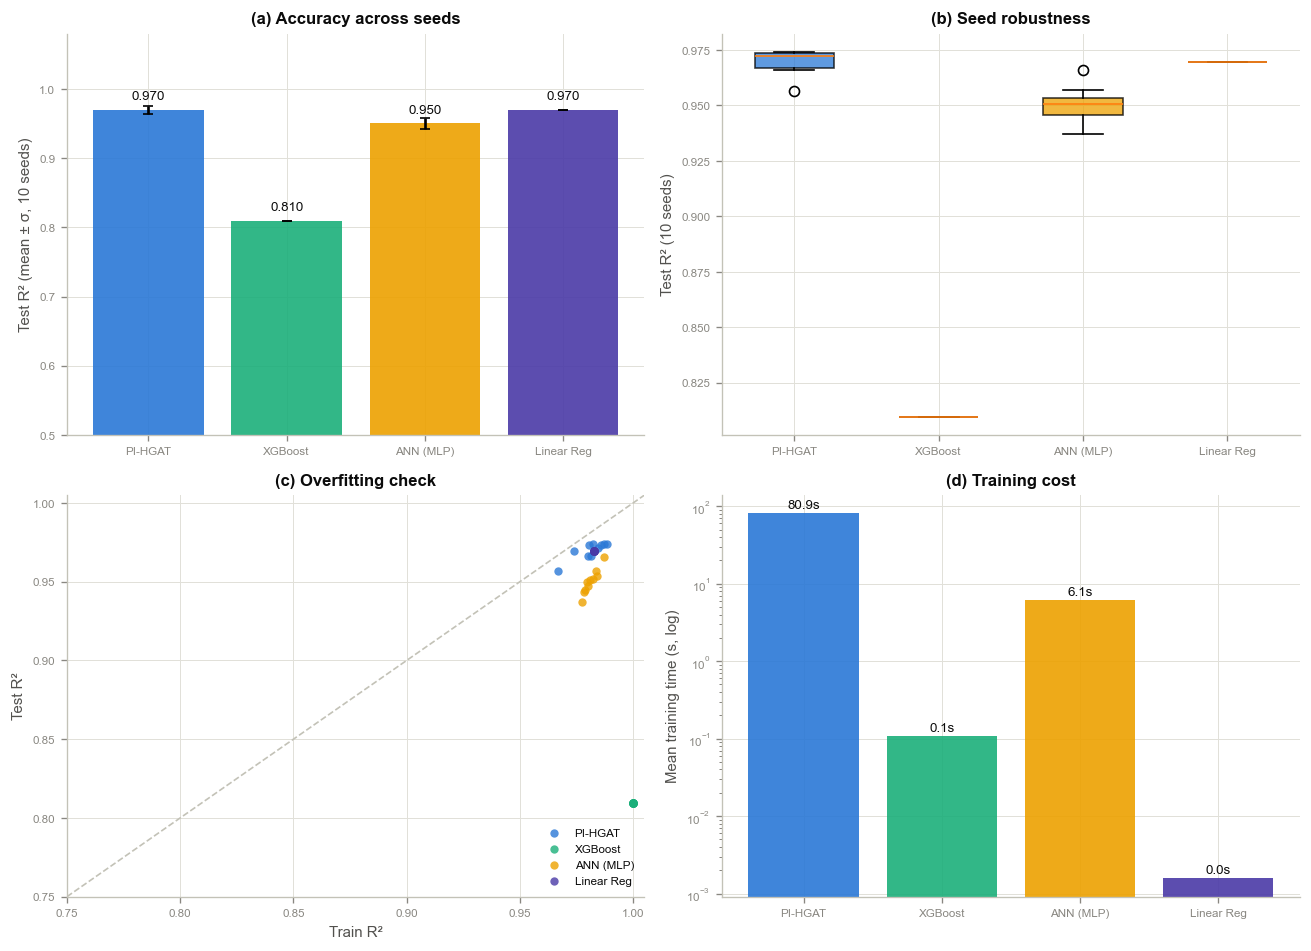

Saved: results/figures/Fig5_LearningCurve.png|.pdf


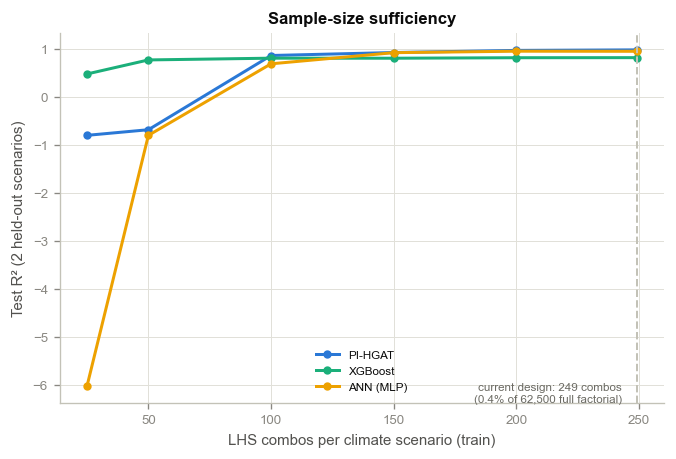

LOSO — test MAE (kWh/m²/yr) per held-out climate scenario:


,model,PI-HGAT,XGBoost,ANN (MLP),Linear Reg
fold_scenario,delta_t,,,,
1_Baseline,0.000,4.68,6.52,1.17,2.49
2,1.879,0.81,0.35,0.62,0.81
3,2.665,0.80,3.48,0.98,0.83
4,2.179,0.72,1.90,1.10,0.80
5,4.472,2.14,9.68,1.47,2.97
6,1.270,0.75,1.87,1.28,0.68
7,1.875,0.70,0.37,1.43,0.56
8,1.611,0.75,1.63,1.11,0.64
9,3.144,0.94,3.53,0.98,0.81



Parameter generalization — unseen combos (GroupSplit by combo_id):


,r2_train,r2_test,rmse,mae,mape
model,,,,,
PI-HGAT,0.9814,0.9801,1.3768,1.0049,0.8285
XGBoost,0.9999,0.9938,0.7693,0.5576,0.4629
ANN (MLP),0.9590,0.8938,3.1765,2.6287,2.2316
Linear Reg,0.9833,0.9811,1.3415,0.9592,0.8062



Physics monotonicity-loss ablation (mean over 3 seeds; viol = finite-diff violation rate):


,r2_test,rmse,viol_wallU,viol_cop,viol_deltaT
variant,,,,,
mono_off,0.9675,1.0499,0.0,0.0167,0.0
mono_on,0.9725,0.9667,0.0,0.0000,0.0


In [ ]:
# S10 — reads artifacts produced by scripts/analysis/step3_robustness.py
from scripts.analysis.fig_style import apply_style, savefig, MODEL_COLORS
import os
apply_style()

ORDER = ['PI-HGAT', 'XGBoost', 'ANN (MLP)', 'Linear Reg']

if not os.path.exists('results/step3_multiseed.csv'):
    print('step3 artifacts not found — run: python scripts/analysis/step3_robustness.py --study all')
else:
    ms = pd.read_csv('results/step3_multiseed.csv')

    # --- FIG 4 (2x2): benchmark & robustness ---
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))

    # (a) test R2, mean +/- sigma over seeds
    ax = axes[0, 0]
    agg = ms.groupby('model')['r2_test'].agg(['mean', 'std']).reindex(ORDER)
    bars = ax.bar(agg.index, agg['mean'], yerr=agg['std'], capsize=3,
                  color=[MODEL_COLORS[m] for m in agg.index], alpha=0.9)
    for b, v in zip(bars, agg['mean']):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.015, f'{v:.3f}',
                ha='center', fontsize=8, fontname='Arial')
    ax.set_ylabel('Test R² (mean ± σ, 10 seeds)')
    ax.set_ylim(0.5, 1.08)
    ax.set_title('(a) Accuracy across seeds', fontweight='bold')

    # (b) boxplot of test R2 across seeds
    ax = axes[0, 1]
    data = [ms.loc[ms.model == m, 'r2_test'].values for m in ORDER]
    bp = ax.boxplot(data, tick_labels=ORDER, patch_artist=True, widths=0.55)
    for patch, m in zip(bp['boxes'], ORDER):
        patch.set_facecolor(MODEL_COLORS[m]); patch.set_alpha(0.75)
    ax.set_ylabel('Test R² (10 seeds)')
    ax.set_title('(b) Seed robustness', fontweight='bold')

    # (c) train vs test R2 (overfitting check)
    ax = axes[1, 0]
    for m in ORDER:
        sub = ms[ms.model == m]
        ax.scatter(sub['r2_train'], sub['r2_test'], s=25, alpha=0.8,
                   color=MODEL_COLORS[m], label=m)
    lims = [0.75, 1.005]
    ax.plot(lims, lims, '--', lw=1, color='#c3c2b7')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Train R²'); ax.set_ylabel('Test R²')
    ax.set_title('(c) Overfitting check', fontweight='bold')
    ax.legend(prop={'size': 7}, loc='lower right')

    # (d) training time (log scale)
    ax = axes[1, 1]
    tim = ms.groupby('model')['fit_seconds'].mean().reindex(ORDER)
    bars = ax.bar(tim.index, tim.values, color=[MODEL_COLORS[m] for m in tim.index], alpha=0.9)
    for b, v in zip(bars, tim.values):
        ax.text(b.get_x() + b.get_width()/2, v * 1.15, f'{v:.1f}s',
                ha='center', fontsize=8, fontname='Arial')
    ax.set_yscale('log')
    ax.set_ylabel('Mean training time (s, log)')
    ax.set_title('(d) Training cost', fontweight='bold')

    for ax in axes.flatten():
        for t in ax.get_xticklabels() + ax.get_yticklabels():
            t.set_fontname('Arial'); t.set_fontsize(7)
    plt.tight_layout()
    savefig(fig, 'Fig4_BenchmarkRobustness')
    plt.show()

    # --- FIG 5: sample-size learning curve (is 250 LHS/scenario enough?) ---
    if os.path.exists('results/step3_learncurve.csv'):
        lc = pd.read_csv('results/step3_learncurve.csv')
        fig, ax = plt.subplots(figsize=(6.5, 4))
        for m in ['PI-HGAT', 'XGBoost', 'ANN (MLP)', 'Linear Reg']:
            sub = lc[lc.model == m].sort_values('n_per_scenario')
            if len(sub):
                ax.plot(sub['n_per_scenario'], sub['r2_test'], marker='o', ms=4,
                        lw=1.8, color=MODEL_COLORS[m], label=m)
        ax.axvline(249, color='#c3c2b7', ls='--', lw=1.2)
        ax.text(243, ax.get_ylim()[0] + 0.02, 'current design: 249 combos\n(0.4% of 62,500 full factorial)',
                ha='right', fontsize=7, fontname='Arial', color='#6b6a63')
        ax.set_xlabel('LHS combos per climate scenario (train)')
        ax.set_ylabel('Test R² (2 held-out scenarios)')
        ax.set_title('Sample-size sufficiency', fontweight='bold')
        ax.legend(prop={'size': 7})
        savefig(fig, 'Fig5_LearningCurve')
        plt.show()

    # --- Table: LOSO per-scenario MAE (climate generalization) ---
    if os.path.exists('results/step3_loso.csv'):
        loso = pd.read_csv('results/step3_loso.csv')
        t_loso = loso.pivot_table(index=['fold_scenario', 'delta_t'],
                                  columns='model', values='mae')[ORDER].round(2)
        print('LOSO — test MAE (kWh/m²/yr) per held-out climate scenario:')
        display(t_loso)
        t_loso.to_csv('results/step3_table_loso_mae.csv')

    # --- Table: parameter generalization (held-out combos, all scenarios) ---
    if os.path.exists('results/step3_combosplit.csv'):
        combo = pd.read_csv('results/step3_combosplit.csv').set_index('model').reindex(ORDER)
        print('\nParameter generalization — unseen combos (GroupSplit by combo_id):')
        display(combo.round(4))

    # --- Table: physics-loss ablation ---
    if os.path.exists('results/step3_ablation.csv'):
        abl = pd.read_csv('results/step3_ablation.csv')
        t_abl = abl.groupby('variant')[['r2_test', 'rmse', 'viol_wallU',
                                        'viol_cop', 'viol_deltaT']].mean().round(4)
        print('\nPhysics monotonicity-loss ablation (mean over 3 seeds; viol = finite-diff violation rate):')
        display(t_abl)


In [ ]:
print(f'\n[Section 10] Execution time: {time.time() - section_10_start:.2f} seconds')


[Section 10] Execution time: 11.70 seconds


## PART 2 · Section 11 — NSGA-III Problem Definition (f1 net-import EUI | f2 LCC | f3 LCE)
**Integer level-index encoding (review fix B2/B3):** each decision variable is the retrofit
level of one measure on the TRUE simulated jEPlus ladder (`config.P*_LEVELS`, 0 = baseline).
This keeps the surrogate strictly in-distribution, keeps P4 glazing a physical catalog pair
(U, SHGC, VT), and matches the registry cost/carbon inventory exactly (L0..Ln).

**Energy flow (review fix B1):** surrogate → GROSS EUI → `objectives.net_energy()` (PV/BESS,
zero-export self-consumption, applied ONCE) → f1 = net-import EUI; f2 = LCC (Kadric Eq. 6–9,
OC on imports); f3 = LCE (EN 15978 A1–A3…C1–C4, B6 on imports). 20-yr / 8%-real basis.
Climate fixed to baseline (ΔT = 0) here; future-climate MOO (ΔT for 2050s/2080s) is Step-4 work.

In [ ]:
import time
section_11_start = time.time()

In [ ]:
from pymoo.core.problem import ElementwiseProblem
from pi_hgat.objectives import ObjectiveCalculator, levels_to_params, N_LEVELS

# Initialize objectives calculator (reads Excel registry LevelInventory)
obj_calc = ObjectiveCalculator(builder)

MEASURE_NAMES = ['P1_Wall', 'P2_Roof', 'P3_CoolRoof', 'P4_Glazing', 'P5_HVAC',
                 'P6_SetPt', 'P7_LED', 'P8_PV', 'P9_BESS']

class NZEBRetrofitProblem(ElementwiseProblem):
    """9 integer variables: x[i] = level index of measure i (0 = baseline).
    Search space = the actual retrofit catalog (5^6 x 4 x 6 x 6 combos)."""

    def __init__(self, model_surrogate, builder, climate_delta_t=0.0):
        super().__init__(n_var=9, n_obj=3, n_ieq_constr=0,
                         xl=np.zeros(9, dtype=int),
                         xu=np.array(N_LEVELS, dtype=int) - 1,
                         vtype=int)
        self.model = model_surrogate
        self.model.eval()
        self.builder = builder
        self.climate_delta_t = climate_delta_t

    def predict_gross_eui(self, params):
        """Surrogate f1 input: GROSS site EUI (demand side, P1-P7 + climate)."""
        data = self.builder.create_sample_graph(params)
        data.global_params = torch.tensor([[params[k] for k in FEATURE_NAMES]],
                                          dtype=torch.float)
        with torch.no_grad():
            batch_dict = {nt: torch.zeros(data[nt].x.size(0), dtype=torch.long, device=device)
                          for nt in data.node_types}
            out_eui = self.model(
                {nt: data[nt].x.to(device) for nt in data.node_types},
                {et: data[et].edge_index.to(device) for et in data.edge_types},
                batch_dict,
                data.global_params.to(device))
        return float(out_eui.item())

    def _evaluate(self, x, out, *args, **kwargs):
        params = levels_to_params(np.rint(x).astype(int), climate_delta_t=self.climate_delta_t)
        gross_eui = self.predict_gross_eui(params)
        # PV/BESS enter ONCE, via the single net-energy model (review fix B1)
        f1 = obj_calc.net_energy(params, gross_eui)['net_eui']   # grid-import EUI
        f2 = obj_calc.calculate_lcc(params, gross_eui)
        f3 = obj_calc.calculate_lca(params, gross_eui)
        out["F"] = [f1, f2, f3]

problem = NZEBRetrofitProblem(model, builder)
print("MOO Problem: 9 integer level variables, 3 objectives (net-import EUI, LCC, LCE)")

p_l0 = levels_to_params([0]*9)
p_lmax = levels_to_params([n-1 for n in N_LEVELS])
val_keys = ['P1_Wall_U', 'P2_Roof_U', 'P3_Roof_Reflectance', 'P4_Win_U',
            'P5_COP', 'P6_Cool_SP', 'P7_LPD', 'P8_PV_kW', 'P9_BESS_kWh']
levels_df = pd.DataFrame({
    'n_levels': N_LEVELS,
    'L0 (baseline)': [round(p_l0[k], 3) for k in val_keys],
    'Lmax': [round(p_lmax[k], 3) for k in val_keys],
}, index=MEASURE_NAMES)
print('\nDecision variables (integer level index -> physical value):')
display(levels_df)

MOO Problem: 9 integer level variables, 3 objectives (net-import EUI, LCC, LCE)

Decision variables (integer level index -> physical value):


,n_levels,L0 (baseline),Lmax
P1_Wall,5,2.083,0.336
P2_Roof,5,0.232,0.147
P3_CoolRoof,4,0.550,0.770
P4_Glazing,5,2.862,1.500
P5_HVAC,5,3.399,4.400
P6_SetPt,5,24.000,26.000
P7_LED,5,6.664,4.000
P8_PV,6,0.000,150.000
P9_BESS,6,0.000,150.000


> ### 📊 FIGURE SLOT — **Fig. 6 · Component lifespans vs 20-yr study period** *(PART 2, setup)*
> Barh lifespan P1–P9 (`config.LIFESPANS_SHORT`) + vạch dọc 20 năm; đánh dấu các measure có replacement (P5@15, P7@12, P9@15). Số liệu THẬT từ config — có thể vẽ ngay. **Status:** ⬜ dễ, làm ngay được
>
> ### 📊 FIGURE SLOT — **Fig. 7 · Embodied LCE by module @ max renovation** *(PART 2, setup)*
> Stacked bar 5 module embodied (A1-A3→C1-C4, ordinal blues `LCA_COLORS`), **B6 loại ra** (theo Kadrić Fig.5); mỗi measure P1–P9 một cột. **Data:** `obj_calc.calculate_lca_breakdown()` @ level max. **Status:** ⬜


Saved: results/figures/Fig6_Lifespan.png|.pdf


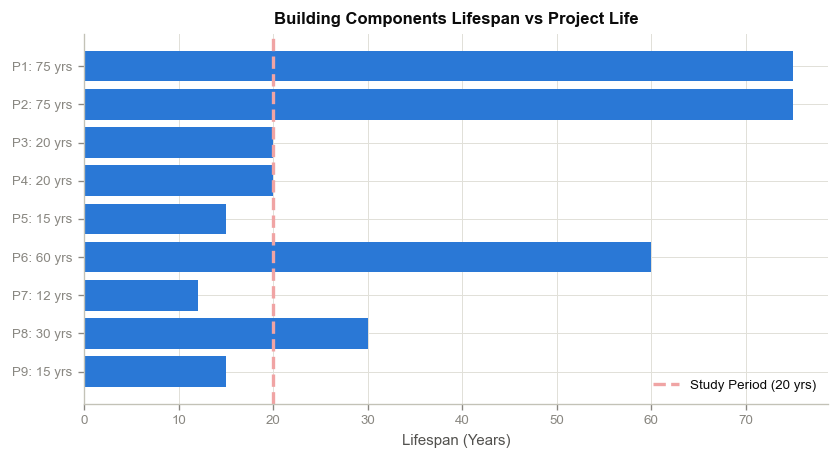

Saved: results/figures/Fig7_LCEDistribution.png|.pdf


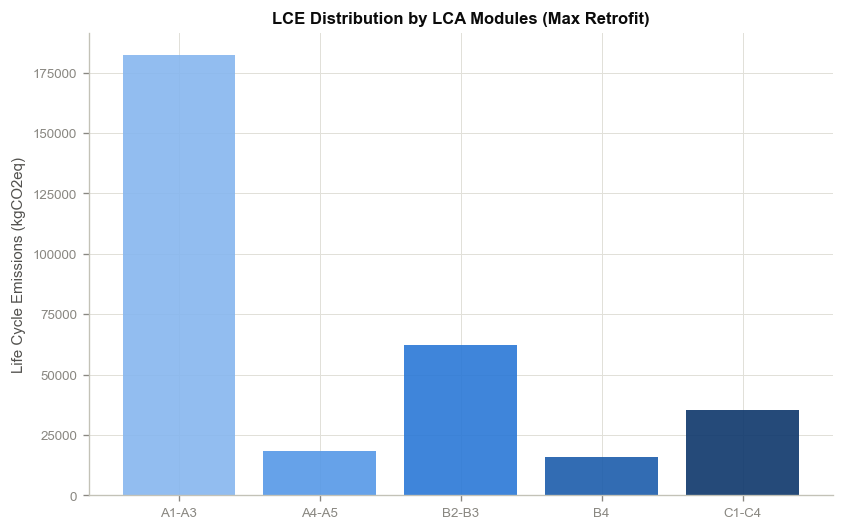

In [ ]:
# FIGURE 3 & 4
from scripts.analysis.fig_style import apply_style, savefig, LCA_COLORS
from pi_hgat.config import LIFESPANS_SHORT
apply_style()

# --- FIG 6: Lifespans ---
fig, ax = plt.subplots(figsize=(8, 4))
components = [f'{k}: {v} yrs' for k, v in LIFESPANS_SHORT.items()]
lifespans = list(LIFESPANS_SHORT.values())
y_pos = np.arange(len(components))
ax.barh(y_pos, lifespans, color='#2a78d6', edgecolor='black')
ax.set_yticks(y_pos)
ax.set_yticklabels(components)
ax.invert_yaxis()
ax.set_xlabel('Lifespan (Years)')
ax.set_title('Building Components Lifespan vs Project Life')
ax.axvline(x=20, color='#f0a4a4', linestyle='--', linewidth=2, label='Study Period (20 yrs)')
ax.legend(loc='lower right')
savefig(fig, 'Fig6_Lifespan')
plt.show()

# --- FIG 7: LCA Modules at Max Level ---
# Max retrofit = highest level on every TRUE simulated ladder (review fix B2:
# the old hardcoded values here came from the stale COST_FACTORS scale)
params_max = levels_to_params([n - 1 for n in N_LEVELS])
lca_breakdown = obj_calc.calculate_lca_breakdown(params_max, 80.0)  # embodied modules only below
modules = ['A1-A3', 'A4-A5', 'B2-B3', 'B4', 'C1-C4']
vals = [lca_breakdown[m] for m in modules]
colors = [LCA_COLORS[m] for m in modules]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(modules, vals, color=colors, edgecolor='black', alpha=0.9)
ax.set_ylabel('Life Cycle Emissions (kgCO2eq)')
ax.set_title('LCE Distribution by LCA Modules (Max Retrofit)')
savefig(fig, 'Fig7_LCEDistribution')
plt.show()

In [ ]:
print(f'\n[Section 11] Execution time: {time.time() - section_11_start:.2f} seconds')


[Section 11] Execution time: 11.26 seconds


## PART 2 · Section 12 — Run NSGA-III
Integer-encoded NSGA-III (IntegerRandomSampling + SBX/PM with RoundingRepair).
Pareto front and convergence are plotted AFTER S13 (Fig. 8 needs TOPSIS closeness).

In [ ]:
import time
section_12_start = time.time()

In [ ]:
from pymoo.algorithms.moo.nsga3 import NSGA3
from pymoo.optimize import minimize
from pymoo.util.ref_dirs import get_reference_directions
from pymoo.operators.sampling.rnd import IntegerRandomSampling
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.repair.rounding import RoundingRepair

# Reference directions for 3 objectives; integer-aware operators for level indices
ref_dirs = get_reference_directions("das-dennis", 3, n_partitions=12)
algorithm = NSGA3(pop_size=124, ref_dirs=ref_dirs,
                  sampling=IntegerRandomSampling(),
                  crossover=SBX(prob=0.9, eta=15, vtype=float, repair=RoundingRepair()),
                  mutation=PM(eta=20, vtype=float, repair=RoundingRepair()),
                  eliminate_duplicates=True)

print("Running NSGA-III (integer level encoding)... (This may take a minute)")
t0 = time.time()
res = minimize(problem,
               algorithm,
               seed=42,
               termination=('n_gen', 100),
               save_history=True,
               verbose=True)

print(f"Optimization finished in {time.time()-t0:.1f}s")
print(f"Found {len(res.F)} Pareto optimal solutions.")

Running NSGA-III (integer level encoding)... (This may take a minute)
n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      124 |      6 |             - |             -
     2 |      248 |      4 |  0.0453780172 |             f
     3 |      372 |      6 |  0.0825391627 |         ideal
     4 |      496 |      5 |  0.0181449444 |             f
     5 |      620 |      7 |  0.0718407947 |             f
     6 |      744 |      4 |  0.0288646538 |         ideal
     7 |      868 |      7 |  0.0094531292 |         ideal
     8 |      992 |      7 |  0.0059680933 |         nadir
     9 |     1116 |     10 |  0.0232845203 |         ideal
    10 |     1240 |     10 |  0.0336871015 |             f
    11 |     1364 |      9 |  0.0032758210 |         ideal
    12 |     1488 |      6 |  0.0030023361 |             f
    13 |     1612 |      9 |  0.0397996398 |             f
    14 |     1736 |      9 |  0.0218971988 |         nadir
    15 |     1860 |     10 |  0.0090054288 | 

In [ ]:
print(f'\n[Section 12] Execution time: {time.time() - section_12_start:.2f} seconds')


[Section 12] Execution time: 89.30 seconds


## PART 2 · Section 13 — Entropy-TOPSIS Ranking & NZE Assessment
Single TOPSIS implementation (`entropy_topsis`) — Fig. 8/9/11 all reuse `closeness`/`best_idx`
computed here (the old duplicated copy inside the Fig. 8 cell was removed).
NZE classification comes from `objectives.assess_nze()` (same `net_energy()` model as f1/f2/f3).
Saves `results/pareto_solutions.csv` (level indices + physical values + F + closeness + NZE class).

In [ ]:
import time
section_13_start = time.time()

In [ ]:
import os

F = res.F
X_lvl = np.rint(res.X).astype(int)

# --- Entropy-TOPSIS (SINGLE implementation; Fig 8/9/11 reuse these results) ---
def entropy_topsis(F):
    """Entropy-weighted TOPSIS for a min-min-min objective matrix F [n_sol, n_obj]."""
    norm_F = F / np.sqrt((F**2).sum(axis=0))
    P = norm_F / norm_F.sum(axis=0)
    E = -np.nansum(P * np.log(P), axis=0) / np.log(len(F))
    W = (1 - E) / (1 - E).sum()
    V = norm_F * W
    ideal, anti_ideal = V.min(axis=0), V.max(axis=0)
    d_ideal = np.sqrt(((V - ideal)**2).sum(axis=1))
    d_anti = np.sqrt(((V - anti_ideal)**2).sum(axis=1))
    return W, d_anti / (d_ideal + d_anti)

W, closeness = entropy_topsis(F)
print(f"Objective Weights (Entropy): EUI={W[0]:.3f}, LCC={W[1]:.3f}, LCE={W[2]:.3f}")

best_idx = int(np.argmax(closeness))
best_levels = X_lvl[best_idx]
best_params = levels_to_params(best_levels)
best_obj = F[best_idx]

# --- NZE assessment per solution (objectives.assess_nze — same net_energy model) ---
val_keys = ['P1_Wall_U', 'P2_Roof_U', 'P3_Roof_Reflectance', 'P4_Win_U', 'P4_Win_SHGC',
            'P5_COP', 'P6_Cool_SP', 'P7_LPD', 'P8_PV_kW', 'P9_BESS_kWh']
rows = []
for i in range(len(F)):
    p_i = levels_to_params(X_lvl[i])
    gross_i = problem.predict_gross_eui(p_i)
    nze_i = obj_calc.assess_nze(p_i, gross_i)
    rows.append({**{f'{m}_lvl': int(X_lvl[i][j]) for j, m in enumerate(MEASURE_NAMES)},
                 **{k: p_i[k] for k in val_keys},
                 'Gross_EUI': gross_i, 'Net_EUI': F[i, 0], 'LCC': F[i, 1], 'LCE': F[i, 2],
                 'Net_balance_EUI': nze_i['net_balance_eui'],
                 'RE_fraction': nze_i['re_fraction'],
                 'Closeness': closeness[i], 'NZE_class': nze_i['nze_class']})
df_pareto = pd.DataFrame(rows).sort_values('Closeness', ascending=False).reset_index(drop=True)

os.makedirs('results', exist_ok=True)
df_pareto.to_csv('results/pareto_solutions.csv', index=False)

nze_best = obj_calc.assess_nze(best_params, problem.predict_gross_eui(best_params))
print("\n===== OPTIMAL COMPROMISE SOLUTION (TOPSIS) =====")
print("Levels: " + ", ".join(f"{m}=L{l}" for m, l in zip(MEASURE_NAMES, best_levels)))
print(f"Net-import EUI: {best_obj[0]:.2f} kWh/m2/yr "
      f"(gross {nze_best['gross_eui']:.2f}, site balance {nze_best['net_balance_eui']:.2f})")
print(f"LCC: ${best_obj[1]:,.0f} | LCE: {best_obj[2]:,.0f} kgCO2eq")
print(f"NZE class: {nze_best['nze_class']} (self-consumed RE fraction {nze_best['re_fraction']:.2f})")
print(f"\nSaved {len(df_pareto)} solutions to results/pareto_solutions.csv")
print(df_pareto['NZE_class'].value_counts())

Objective Weights (Entropy): EUI=0.196, LCC=0.636, LCE=0.168

===== OPTIMAL COMPROMISE SOLUTION (TOPSIS) =====
Levels: P1_Wall=L0, P2_Roof=L0, P3_CoolRoof=L0, P4_Glazing=L0, P5_HVAC=L0, P6_SetPt=L2, P7_LED=L4, P8_PV=L5, P9_BESS=L0
Net-import EUI: 89.36 kWh/m2/yr (gross 115.02, site balance 72.26)
LCC: $706,420 | LCE: 6,113,493 kgCO2eq
NZE class: Below target (self-consumed RE fraction 0.22)

Saved 11 solutions to results/pareto_solutions.csv
NZE_class
Below target    11
Name: count, dtype: int64


> ### 📊 FIGURE SLOT — **Fig. 8 · Pareto front + convergence** *(PART 2)*
> (a) 3D Pareto (EUI–LCC–LCE) màu TOPSIS (`seq_cmap`); (b) hypervolume theo generation (cần `save_history=True` trong `minimize`). **THAY THẾ** Fig7 mock "evolution" cũ — hypervolume là bằng chứng hội tụ chuẩn hơn scatter. **Status:** ⬜


Saved: results/figures/Fig8_Pareto3D.png|.pdf


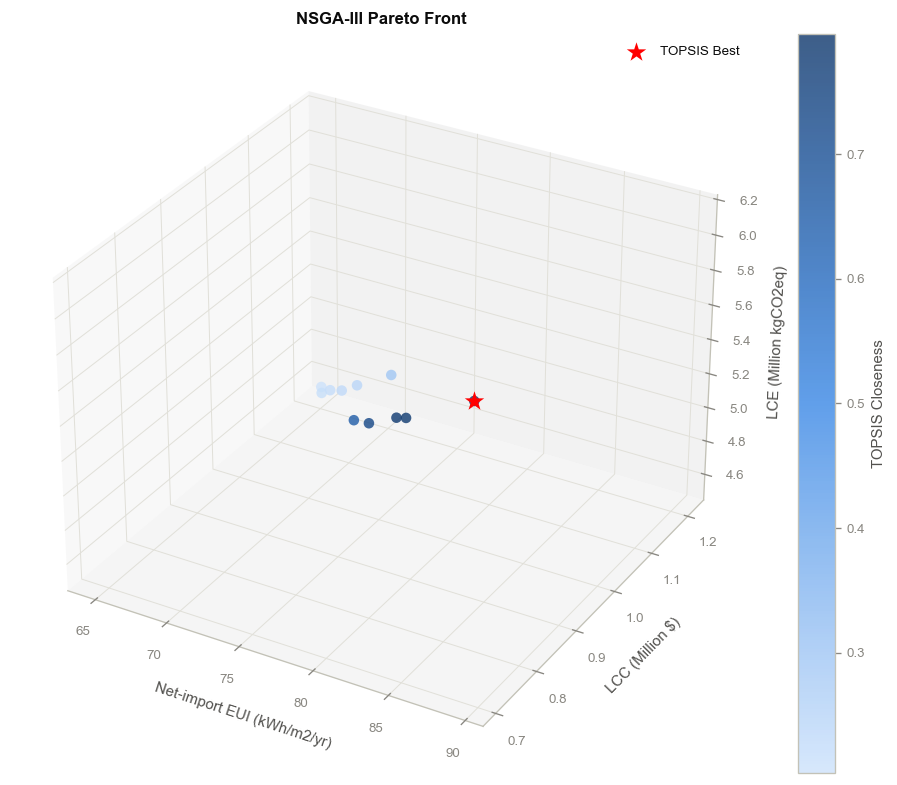

Saved: results/figures/Fig8b_Convergence.png|.pdf


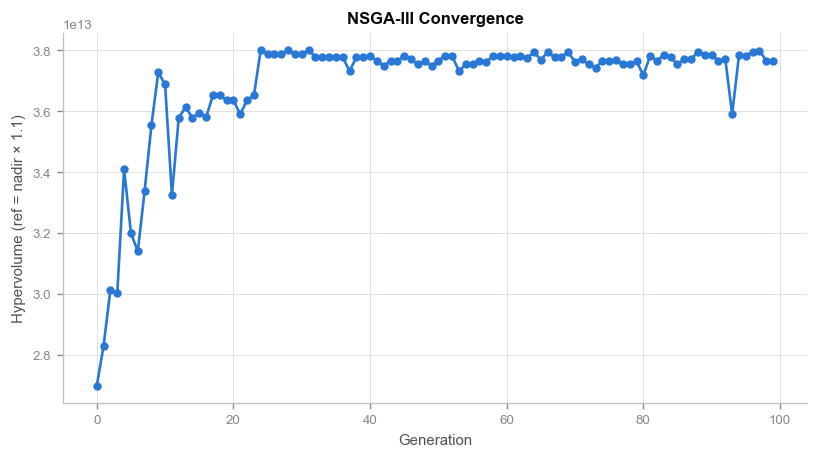

In [ ]:
# FIGURE 8 — uses closeness/best_idx from S13 (single TOPSIS implementation)
from scripts.analysis.fig_style import apply_style, savefig, seq_cmap
apply_style()

F = res.F
best_obj = F[best_idx]

# --- FIG 8a: 3D Pareto ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(F[:, 0], F[:, 1]/1e6, F[:, 2]/1e6, c=closeness, cmap=seq_cmap(), s=40, alpha=0.8)
ax.scatter(best_obj[0], best_obj[1]/1e6, best_obj[2]/1e6, color='red', s=150, marker='*', label='TOPSIS Best')

ax.set_xlabel('Net-import EUI (kWh/m2/yr)')
ax.set_ylabel('LCC (Million $)')
ax.set_zlabel('LCE (Million kgCO2eq)')
ax.set_title('NSGA-III Pareto Front')
plt.colorbar(sc, label='TOPSIS Closeness')
plt.legend()
savefig(fig, 'Fig8_Pareto3D')
plt.show()

# --- FIG 8b: Convergence (Hypervolume) ---
if res.history is not None:
    from pymoo.indicators.hv import Hypervolume
    # Documented ref point: 10% beyond the nadir over all generations' fronts
    F_all = np.vstack([a.opt.get("F") for a in res.history if len(a.opt) > 0])
    ref_point = F_all.max(axis=0) * 1.1
    hv = Hypervolume(ref_point=ref_point)
    hv_history = [hv.do(a.opt.get("F")) if len(a.opt) > 0 else 0.0 for a in res.history]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(hv_history, color='#2a78d6', marker='o', markersize=4)
    ax.set_xlabel('Generation')
    ax.set_ylabel('Hypervolume (ref = nadir × 1.1)')
    ax.set_title('NSGA-III Convergence')
    savefig(fig, 'Fig8b_Convergence')
    plt.show()

> ### 📊 FIGURE SLOT — **Fig. 9 · Pairwise Pareto colored by TOPSIS** *(PART 2)*
> 3 panel EUI–LCC / EUI–LCE / LCC–LCE, màu = closeness (`seq_cmap`), ★ = compromise. GỘP Fig3 (pairwise trơn) vào đây — Fig3 cũ **bỏ** vì trùng. **Status:** ⬜
>
> ### 📊 FIGURE SLOT — **Fig. 10 · LCE by module: Baseline vs Optimal vs Max** *(PART 2)*
> GỘP Fig5-cũ + Fig10-cũ thành 1 hình 3 cột nhóm (module màu `LCA_COLORS` + B6 aqua) — kể trọn câu chuyện NZEB-paradox trong 1 hình. **Data:** `calculate_lca_breakdown()` cho 3 cấu hình. **Status:** ⬜
>
> ### 📊 FIGURE SLOT — **Fig. 11 · Renovation-level heatmap of Pareto set** *(PART 2)*
> Heatmap (P1–P9 × solutions xếp theo TOPSIS, `seq_cmap`, level chuẩn hóa 0–1). **Kadrić Fig.11.** **Status:** ⬜
>
> **💾 REQUIRED:** lưu `res.X`, `res.F`, `closeness` → `results/pareto_solutions.csv` so all figures are reproducible.


Saved: results/figures/Fig9_Pairwise.png|.pdf


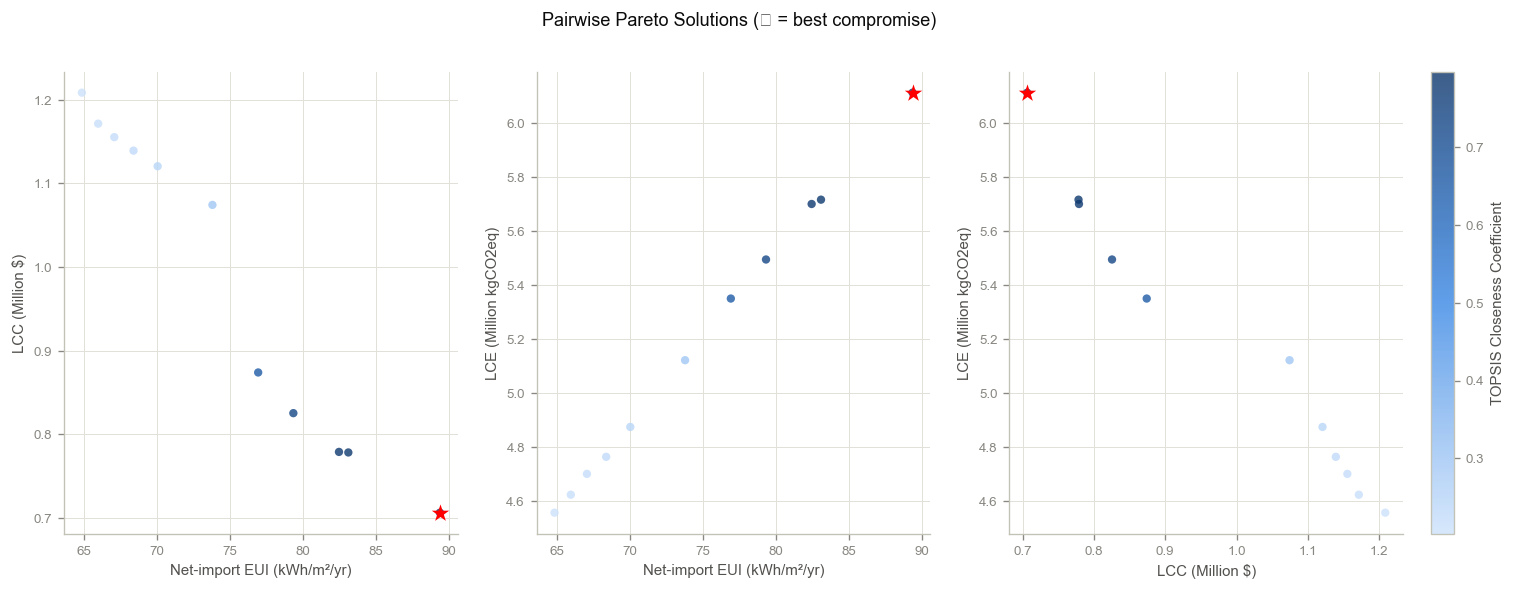

Saved: results/figures/Fig11_Heatmap.png|.pdf


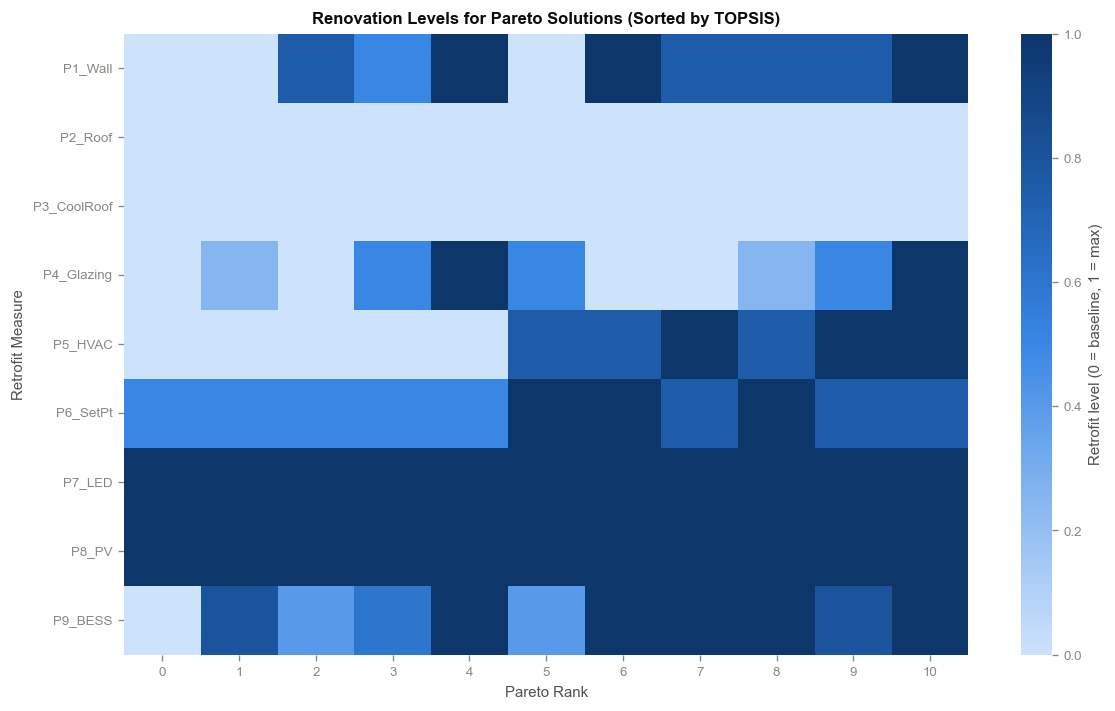

In [ ]:
# FIGURE 9, 10, 11
from scripts.analysis.fig_style import apply_style, savefig, seq_cmap
import seaborn as sns
apply_style()

# --- FIG 9: Pairwise Pareto (coloured by TOPSIS closeness from S13) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
labels = ['Net-import EUI (kWh/m²/yr)', 'LCC (Million $)', 'LCE (Million kgCO2eq)']
pairs = [(0, 1), (0, 2), (1, 2)]

for i, ax in enumerate(axes):
    idx_x, idx_y = pairs[i]
    x_data = F[:, idx_x] if idx_x == 0 else F[:, idx_x] / 1e6
    y_data = F[:, idx_y] if idx_y == 0 else F[:, idx_y] / 1e6
    
    sc = ax.scatter(x_data, y_data, c=closeness, cmap=seq_cmap(), s=25, alpha=0.8)
    bx = F[best_idx, idx_x] if idx_x == 0 else F[best_idx, idx_x] / 1e6
    by = F[best_idx, idx_y] if idx_y == 0 else F[best_idx, idx_y] / 1e6
    ax.scatter(bx, by, color='red', s=120, marker='*', zorder=5)
    ax.set_xlabel(labels[idx_x])
    ax.set_ylabel(labels[idx_y])

cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label('TOPSIS Closeness Coefficient')
fig.suptitle('Pairwise Pareto Solutions (★ = best compromise)')
savefig(fig, 'Fig9_Pairwise')
plt.show()

# --- FIG 11: Heatmap of integer retrofit levels (sorted by TOPSIS) ---
df_p = pd.read_csv('results/pareto_solutions.csv')   # already sorted by Closeness desc
lvl_cols = [f'{m}_lvl' for m in MEASURE_NAMES]
X_norm = df_p[lvl_cols].values / (np.array(N_LEVELS) - 1)   # 0 = baseline, 1 = max level

plt.figure(figsize=(10, 6))
sns.heatmap(X_norm.T, cmap=seq_cmap(),
            cbar_kws={'label': 'Retrofit level (0 = baseline, 1 = max)'},
            yticklabels=MEASURE_NAMES)
plt.title('Renovation Levels for Pareto Solutions (Sorted by TOPSIS)')
plt.xlabel('Pareto Rank')
plt.ylabel('Retrofit Measure')
plt.tight_layout()
savefig(plt.gcf(), 'Fig11_Heatmap')
plt.show()

> ### 📊 FIGURE SLOT — **Fig. 10 · LCE by module: Baseline vs Optimal vs Max** *(PART 2)*
> Grouped bars per EN 15978 module (incl. **B6** operational) for 3 configurations — the
> NZEB-paradox story: deep retrofit trades operational carbon (B6↓) for embodied carbon (A/B4/C↑).
> Data: `calculate_lca_breakdown()` @ surrogate-predicted gross EUI. **+ Table:** top-10 Pareto.

Saved: results/figures/Fig10_LCEComparison.png|.pdf


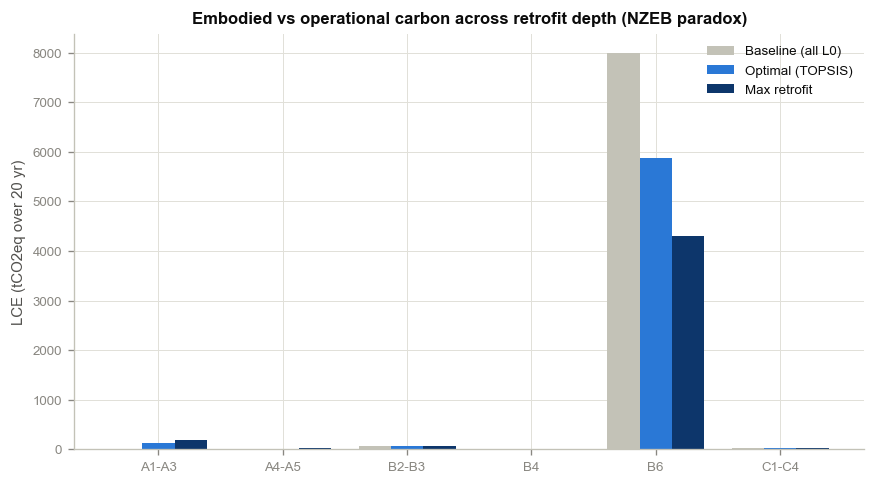

Top-10 Pareto solutions (sorted by TOPSIS closeness):


,P1_Wall_lvl,P2_Roof_lvl,P3_CoolRoof_lvl,P4_Glazing_lvl,P5_HVAC_lvl,P6_SetPt_lvl,P7_LED_lvl,P8_PV_lvl,P9_BESS_lvl,Gross_EUI,Net_EUI,LCC,LCE,RE_fraction,Closeness,NZE_class
0,0,0,0,0,0,2,4,5,0,115.02,89.36,706419.71,6113493.31,0.22,0.80,Below target
1,0,0,0,1,0,2,4,5,4,111.62,82.45,779051.59,5701181.09,0.26,0.79,Below target
2,3,0,0,0,0,2,4,5,2,110.50,83.09,778395.70,5717157.97,0.25,0.78,Below target
3,2,0,0,2,0,2,4,5,3,107.61,79.32,825386.06,5495570.89,0.26,0.73,Below target
4,4,0,0,4,0,2,4,5,5,106.96,76.91,874018.54,5350956.92,0.28,0.66,Below target
5,0,0,0,2,3,4,4,5,2,101.19,73.78,1074341.23,5122615.06,0.27,0.30,Below target
6,4,0,0,0,3,4,4,5,5,100.08,70.03,1120551.64,4875372.18,0.30,0.24,Below target
7,3,0,0,0,4,3,4,5,5,98.43,68.37,1139217.71,4764735.45,0.31,0.23,Below target
8,3,0,0,1,3,4,4,5,5,97.11,67.05,1155355.26,4701465.70,0.31,0.22,Below target
9,3,0,0,2,4,3,4,5,4,95.12,65.95,1171470.61,4624426.76,0.31,0.22,Below target


In [ ]:
# FIG 10 — LCE by module for Baseline / TOPSIS-optimal / Max retrofit (+ top-10 Pareto table)
from scripts.analysis.fig_style import apply_style, savefig
apply_style()

configs = {
    'Baseline (all L0)': levels_to_params([0] * 9),
    'Optimal (TOPSIS)': best_params,
    'Max retrofit': levels_to_params([n - 1 for n in N_LEVELS]),
}
modules = ['A1-A3', 'A4-A5', 'B2-B3', 'B4', 'B6', 'C1-C4']
lce = {}
for label, p in configs.items():
    gross = problem.predict_gross_eui(p)
    bd = obj_calc.calculate_lca_breakdown(p, gross)
    lce[label] = [bd[m] / 1e3 for m in modules]   # tCO2eq

x = np.arange(len(modules)); w = 0.26
shades = ['#c3c2b7', '#2a78d6', '#0d366b']
fig, ax = plt.subplots(figsize=(8.5, 4.5))
for j, (label, v) in enumerate(lce.items()):
    bars = ax.bar(x + (j - 1) * w, v, width=w, label=label, color=shades[j])
ax.set_xticks(x); ax.set_xticklabels(modules)
ax.set_ylabel('LCE (tCO2eq over 20 yr)')
ax.set_title('Embodied vs operational carbon across retrofit depth (NZEB paradox)')
ax.legend(prop={'size': 8})
savefig(fig, 'Fig10_LCEComparison')
plt.show()

cols10 = [f'{m}_lvl' for m in MEASURE_NAMES] + ['Gross_EUI', 'Net_EUI', 'LCC', 'LCE',
                                                'RE_fraction', 'Closeness', 'NZE_class']
print('Top-10 Pareto solutions (sorted by TOPSIS closeness):')
display(df_pareto[cols10].head(10).round(2))

In [ ]:
print(f'\n[Section 13] Execution time: {time.time() - section_13_start:.2f} seconds')


[Section 13] Execution time: 29.34 seconds


## PART 2 · Section 14 — Decision Sensitivity & Climate-Aware MOO (Step 4)
**(a) TOPSIS weight sensitivity:** best compromise under entropy / equal / cost-priority /
carbon-priority weights — shows how robust the recommendation is to the weighting choice.
**(b) Climate-aware optimization (Fig. C5):** NSGA-III re-run at ΔT = median-future and
worst-2080s (both within the trained ΔT range 0–4.47) — the paper's key novelty payoff:
*how should the retrofit package change when designing for future climate?*

In [ ]:
import time
section_14_start = time.time()

TOPSIS weight sensitivity (baseline climate):


,"w (EUI, LCC, LCE)",Best package,Net EUI,LCC ($),LCE (t)
Weighting,,,,,
Entropy (objective),"(0.196, 0.636, 0.168)",L0 L0 L0 L0 L0 L2 L4 L5 L0,89.4,706420,6113.5
Equal (1/3),"(0.333, 0.333, 0.333)",L2 L0 L0 L2 L0 L2 L4 L5 L3,79.3,825386,5495.6
Cost-priority,"(0.2, 0.6, 0.2)",L0 L0 L0 L0 L0 L2 L4 L5 L0,89.4,706420,6113.5
Carbon-priority,"(0.2, 0.2, 0.6)",L3 L0 L0 L2 L4 L3 L4 L5 L4,66.0,1171471,4624.4


Median future +2.03°C: 15 Pareto solutions
Worst 2080s +4.47°C: 13 Pareto solutions
Saved: results/figures/FigC5_ClimateMOO.png|.pdf


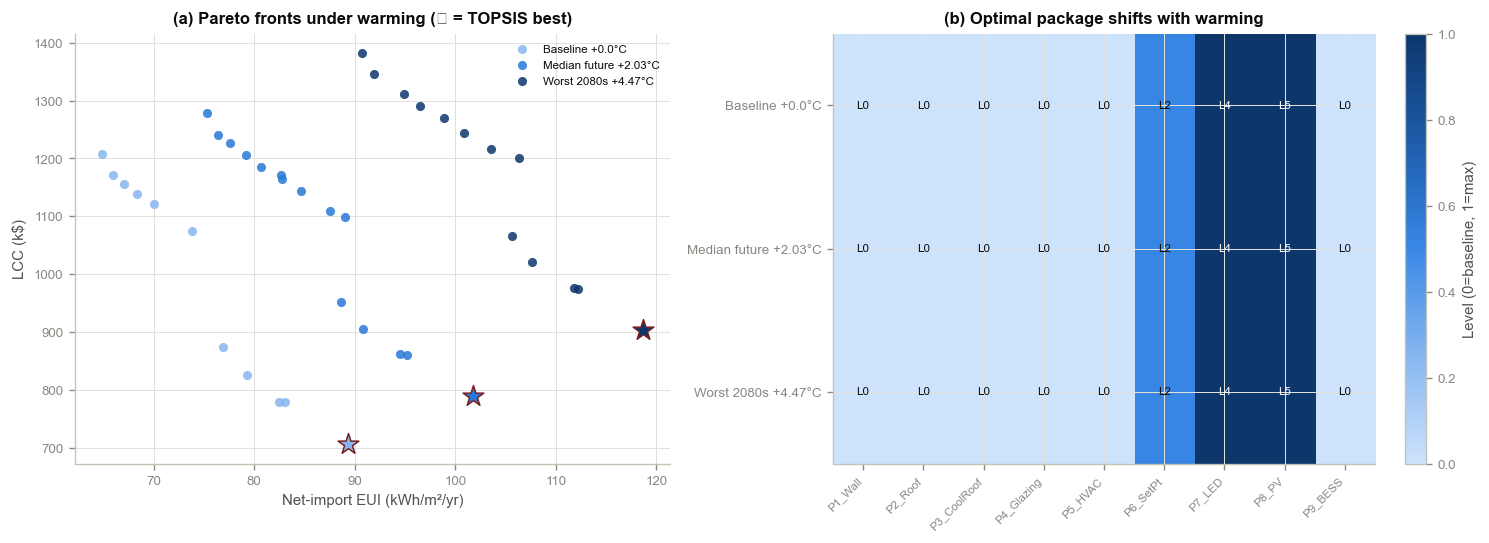

,Package,Net EUI,LCC ($),LCE (t)
Climate,,,,
Baseline +0.0°C,L0 L0 L0 L0 L0 L2 L4 L5 L0,89.4,706420,6113.5
Median future +2.03°C,L0 L0 L0 L0 L0 L2 L4 L5 L0,101.7,789162,6924.5
Worst 2080s +4.47°C,L0 L0 L0 L0 L0 L2 L4 L5 L0,118.7,903103,8041.3


In [ ]:
# S15 — (a) TOPSIS weight sensitivity + (b) climate-aware MOO (FIG C5)
from scripts.analysis.fig_style import apply_style, savefig, seq_cmap
apply_style()

# ---- (a) weight sensitivity on the baseline-climate Pareto front ----
def topsis_fixed(F, Wf):
    nF = F / np.sqrt((F**2).sum(axis=0))
    V = nF * Wf
    ideal, anti = V.min(axis=0), V.max(axis=0)
    d_i = np.sqrt(((V - ideal)**2).sum(axis=1))
    d_a = np.sqrt(((V - anti)**2).sum(axis=1))
    return d_a / (d_i + d_a)

weight_sets = {'Entropy (objective)': W, 'Equal (1/3)': np.array([1/3, 1/3, 1/3]),
               'Cost-priority': np.array([0.2, 0.6, 0.2]),
               'Carbon-priority': np.array([0.2, 0.2, 0.6])}
sens_rows = []
for name, wf in weight_sets.items():
    cl = topsis_fixed(F, wf)
    b = int(np.argmax(cl))
    sens_rows.append({'Weighting': name,
                      'w (EUI, LCC, LCE)': tuple(np.round(wf, 3)),
                      'Best package': ' '.join(f'L{v}' for v in X_lvl[b]),
                      'Net EUI': round(F[b, 0], 1),
                      'LCC ($)': int(round(F[b, 1])),
                      'LCE (t)': round(F[b, 2] / 1e3, 1)})
print('TOPSIS weight sensitivity (baseline climate):')
display(pd.DataFrame(sens_rows).set_index('Weighting'))

# ---- (b) climate-aware MOO ----
futures_dt = df_lhs.groupby(df_lhs['Scenario'].astype(str))['Climate_DeltaT'].first().drop('1_Baseline')
dt_runs = {'Baseline +0.0°C': 0.0,
           f'Median future +{futures_dt.median():.2f}°C': float(futures_dt.median()),
           f'Worst 2080s +{futures_dt.max():.2f}°C': float(futures_dt.max())}
fronts = {}
for label, dt in dt_runs.items():
    if dt == 0.0:
        fronts[label] = (res.F, X_lvl)          # reuse the S12 run
        continue
    prob_dt = NZEBRetrofitProblem(model, builder, climate_delta_t=dt)
    alg = NSGA3(pop_size=124, ref_dirs=ref_dirs,
                sampling=IntegerRandomSampling(),
                crossover=SBX(prob=0.9, eta=15, vtype=float, repair=RoundingRepair()),
                mutation=PM(eta=20, vtype=float, repair=RoundingRepair()),
                eliminate_duplicates=True)
    r = minimize(prob_dt, alg, seed=42, termination=('n_gen', 100), verbose=False)
    fronts[label] = (r.F, np.rint(r.X).astype(int))
    print(f'{label}: {len(r.F)} Pareto solutions')

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
shades = ['#86b6ef', '#2a78d6', '#0d366b']
best_rows = []
for (label, (Fd, Xd)), c in zip(fronts.items(), shades):
    axes[0].scatter(Fd[:, 0], Fd[:, 1] / 1e3, s=30, color=c, alpha=0.85, label=label)
    _, cl = entropy_topsis(Fd)
    b = int(np.argmax(cl))
    axes[0].scatter(Fd[b, 0], Fd[b, 1] / 1e3, s=170, marker='*', color=c,
                    edgecolor='#7a1f1f', linewidth=0.9, zorder=5)
    best_rows.append((label, Xd[b], Fd[b]))
axes[0].set_xlabel('Net-import EUI (kWh/m²/yr)')
axes[0].set_ylabel('LCC (k$)')
axes[0].set_title('(a) Pareto fronts under warming (★ = TOPSIS best)')
axes[0].legend(prop={'size': 7})

lvl_mat = np.array([r[1] for r in best_rows]) / (np.array(N_LEVELS) - 1)
im = axes[1].imshow(lvl_mat, cmap=seq_cmap(), aspect='auto', vmin=0, vmax=1)
axes[1].set_xticks(range(9))
axes[1].set_xticklabels(MEASURE_NAMES, rotation=45, ha='right', fontsize=7)
axes[1].set_yticks(range(len(best_rows)))
axes[1].set_yticklabels([r[0] for r in best_rows], fontsize=8)
for ii, (_, lv, _) in enumerate(best_rows):
    for jj, v in enumerate(lv):
        axes[1].text(jj, ii, f'L{v}', ha='center', va='center', fontsize=7,
                     color='white' if lvl_mat[ii, jj] > 0.5 else '#0b0b0b')
axes[1].set_title('(b) Optimal package shifts with warming')
fig.colorbar(im, ax=axes[1], fraction=0.04, label='Level (0=baseline, 1=max)')
plt.tight_layout()
savefig(fig, 'FigC5_ClimateMOO')
plt.show()

cmp_rows = [{'Climate': label,
             'Package': ' '.join(f'L{v}' for v in lv),
             'Net EUI': round(Fb[0], 1), 'LCC ($)': int(round(Fb[1])),
             'LCE (t)': round(Fb[2] / 1e3, 1)}
            for label, lv, Fb in best_rows]
display(pd.DataFrame(cmp_rows).set_index('Climate'))

In [ ]:
print(f'\n[Section 14] Execution time: {time.time() - section_14_start:.2f} seconds')


[Section 14] Execution time: 163.71 seconds


## PART 3 · Section 15 — Spatial Explainability (GNNExplainer)
Explains the recommended retrofit package: which zones/surfaces/edges drive the EUI
prediction (paper Fig.: explanation subgraph + trade-off report).


In [ ]:
import time
section_15_start = time.time()

In [ ]:
from torch_geometric.explain import Explainer, GNNExplainer

# Best compromise solution from S13 (best_params: physical values mapped from level indices)
print("Explaining TOPSIS best solution:",
      ", ".join(f"{m}=L{l}" for m, l in zip(MEASURE_NAMES, best_levels)))

data = builder.create_sample_graph(best_params)
data.global_params = torch.tensor([[best_params[k] for k in FEATURE_NAMES]], dtype=torch.float)

batch_dict = {nt: torch.zeros(data[nt].x.size(0), dtype=torch.long, device=device) for nt in data.node_types}
data = data.to(device)
data.global_params = data.global_params.to(device)

class ModelWrapper(torch.nn.Module):
    def __init__(self, model, batch_dict, global_params):
        super().__init__()
        self.model = model
        self.batch_dict = batch_dict
        self.global_params = global_params
    def forward(self, x_dict, edge_index_dict):
        return self.model(x_dict, edge_index_dict, self.batch_dict, self.global_params)

wrapped_model = ModelWrapper(model, batch_dict, data.global_params)

explainer = Explainer(
    model=wrapped_model,
    algorithm=GNNExplainer(epochs=200),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=dict(mode='regression', task_level='graph', return_type='raw')
)

print("Running GNNExplainer (learning masks for mutual information)...")
explanation = explainer(data.x_dict, data.edge_index_dict)
print("Explanation completed.")

feat_names = {
    'Zone': ['area', 'volume', 'height', 'LPD'],
    'Envelope': ['area', 'tilt', 'azimuth', 'is_wall', 'is_roof', 'is_floor', 'is_window', 'U-value', 'Reflectance', 'SHGC', 'ShapeIndex'],
    'System': ['cooling_cap', 'heating_cap', 'COP', 'Cool_SP', 'Heat_SP']
}

print("\n--- Top Node Features by Mask Score ---")
for nt in ['Zone', 'Envelope', 'System']:
    mask = explanation.node_mask_dict[nt].cpu().numpy()
    mean_mask = mask.mean(axis=0)
    top_idx = mean_mask.argsort()[::-1][:3]
    print(f"\n{nt} Features:")
    for i in top_idx:
        print(f"  - {feat_names[nt][i]}: {mean_mask[i]:.4f}")

Explaining TOPSIS best solution: P1_Wall=L0, P2_Roof=L0, P3_CoolRoof=L0, P4_Glazing=L0, P5_HVAC=L0, P6_SetPt=L2, P7_LED=L4, P8_PV=L5, P9_BESS=L0
Running GNNExplainer (learning masks for mutual information)...
Explanation completed.

--- Top Node Features by Mask Score ---

Zone Features:
  - volume: 0.7242
  - LPD: 0.2765
  - height: 0.2548

Envelope Features:
  - ShapeIndex: 0.7741
  - tilt: 0.7731
  - area: 0.5079

System Features:
  - Heat_SP: 0.8228
  - COP: 0.8083
  - cooling_cap: 0.8047


> ### 📊 FIGURE SLOT — **Fig. 12 · Global feature importance per node type** *(PART 3)*
> Barh mask score GNNExplainer nhóm theo Zone/Envelope/System (kiểu GAT-BEM Fig.3–8) + SHAP beeswarm trên global params (XGBoost surrogate đối chiếu, `div_cmap` xanh↔đỏ). **Status:** ⬜
>
> ### 📊 FIGURE SLOT — **Fig. 13 · Edge-type (connection) importance** *(PART 3)*
> Bar importance theo edge type (Zone–Envelope, Zone–System, Zone–Zone adjacency…) từ `explanation.edge_mask_dict` — GAT-BEM Fig.9. Đây là bằng chứng "bảo toàn quan hệ không gian". **Status:** ⬜
>
> ### 📊 FIGURE SLOT — **Fig. 14 · Spatial explanation map** *(PART 3 — contribution figure)*
> Floor-plan/axonometric DOE Medium Office, zone tô màu theo node-importance (`seq_cmap`) + top-k edges vẽ đè; kèm (b) scatter centrality-vs-importance (GAT-BEM Fig.10 "thermal centrality"). **Status:** ⬜


Saved: results/figures/Fig12a_NodeImportance.png|.pdf


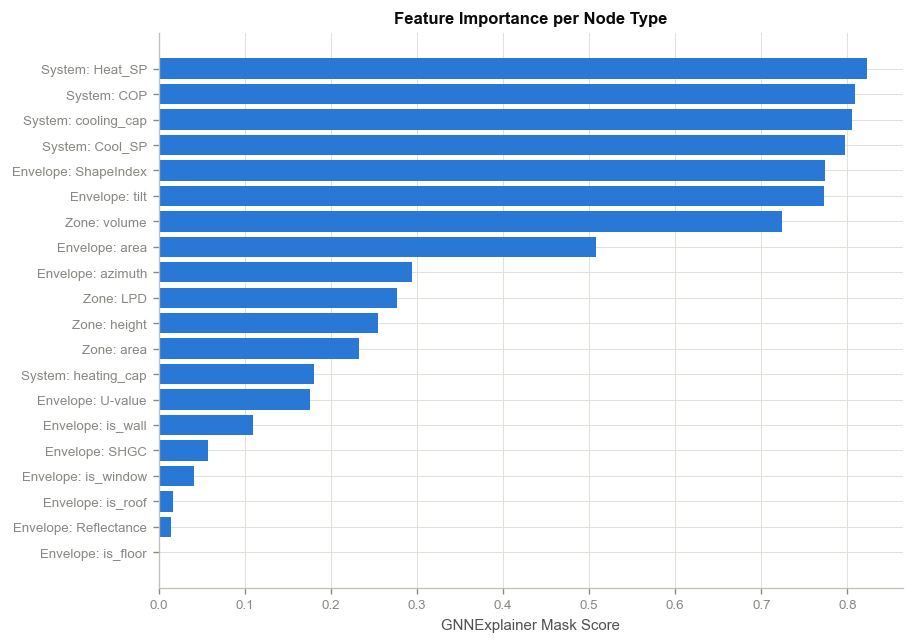

Saved: results/figures/Fig12b_SHAP.png|.pdf


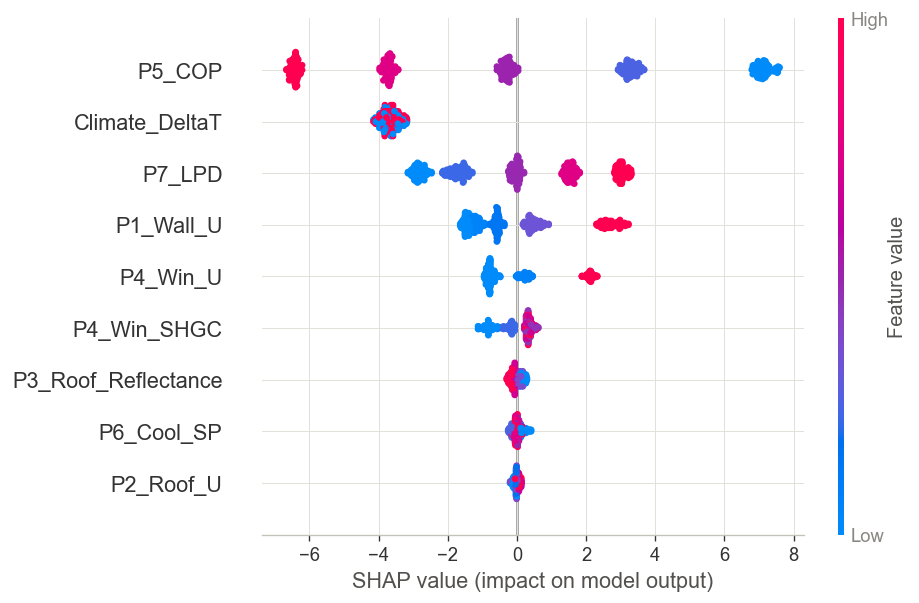

Saved: results/figures/Fig13_EdgeImportance.png|.pdf


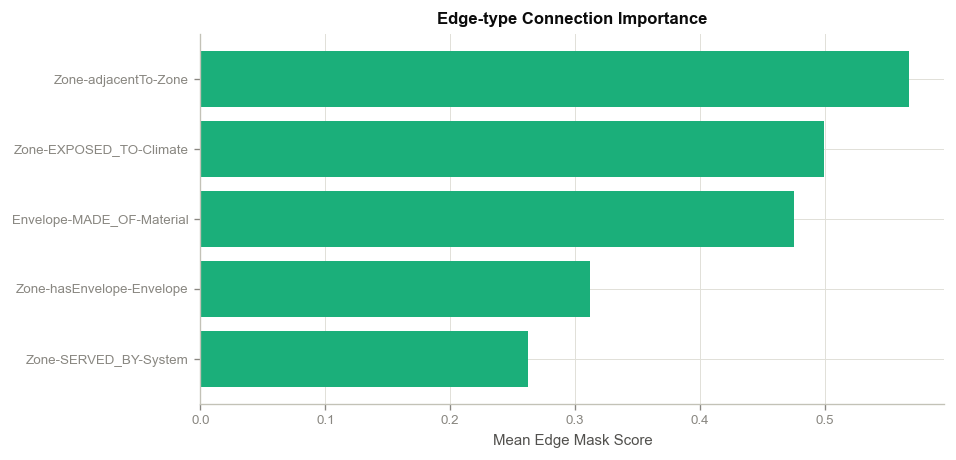

In [ ]:
# FIGURE 12, 13, 14
from scripts.analysis.fig_style import apply_style, savefig
import shap
apply_style()

# --- FIG 12a: Global Feature Importance (GNNExplainer) ---
importances = []
labels = []
for nt in ['Zone', 'Envelope', 'System']:
    mask = explanation.node_mask_dict[nt].cpu().numpy().mean(axis=0)
    for i, score in enumerate(mask):
        importances.append(score)
        labels.append(f"{nt}: {feat_names[nt][i]}")
        
idx = np.argsort(importances)
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(np.array(labels)[idx], np.array(importances)[idx], color='#2a78d6')
ax.set_xlabel('GNNExplainer Mask Score')
ax.set_title('Feature Importance per Node Type')
savefig(fig, 'Fig12a_NodeImportance')
plt.show()

# --- FIG 12b: SHAP Beeswarm (XGBoost cross-check, 9 gross-EUI features) ---
explainer_xgb = shap.Explainer(xgb_model)
shap_values = explainer_xgb(Xte_s)

plt.figure(figsize=(8, 6))
# display RAW (unstandardized) feature values so the colour axis is physically readable
shap.summary_plot(shap_values.values, Xte, feature_names=FEATURE_NAMES, show=False)
savefig(plt.gcf(), 'Fig12b_SHAP')
plt.show()

# --- FIG 13: Edge-type Importance ---
edge_importances = []
edge_labels = []
for et in data.edge_types:
    mask = explanation.edge_mask_dict[et].cpu().numpy().mean()
    edge_importances.append(mask)
    edge_labels.append(f"{et[0]}-{et[1]}-{et[2]}")
    
idx_e = np.argsort(edge_importances)
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(np.array(edge_labels)[idx_e], np.array(edge_importances)[idx_e], color='#1baf7a')
ax.set_xlabel('Mean Edge Mask Score')
ax.set_title('Edge-type Connection Importance')
savefig(fig, 'Fig13_EdgeImportance')
plt.show()

In [ ]:
print(f'\n[Section 15] Execution time: {time.time() - section_15_start:.2f} seconds')


[Section 15] Execution time: 7.16 seconds


## PART 3 · Section 16 — Spatial Explanation Map & Explainer Fidelity (Fig. 14)
**(a)** DOE Medium Office floor plans (schematic) with zones coloured by mean GNNExplainer
importance — the "where does the model look" contribution figure (GAT-BEM Fig. 10 style).
**(b)** zone importance vs KG degree centrality. **Table:** Fidelity+/− and sparsity of the
explanation (top-25% edges) — quantitative evidence the explanation is faithful.

In [ ]:
import time
section_16_start = time.time()

Saved: results/figures/Fig14_SpatialExplanation.png|.pdf


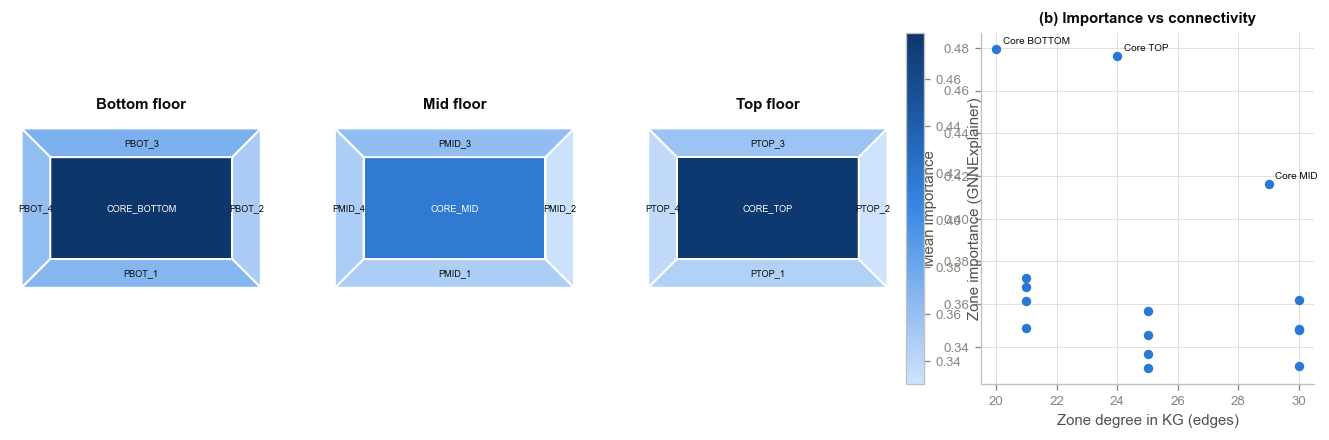

GNNExplainer fidelity — deviation in kWh/m²/yr (high Fid+, low Fid− = faithful):


,"Prediction, full graph (kWh/m²)",Fidelity+ (drop top-25% edges),Fidelity− (keep only top-25%),Sparsity
0,120.26,5.12,1.21,0.75


In [ ]:
# S16 — FIG 14 spatial explanation + centrality + explainer fidelity table
from scripts.analysis.fig_style import apply_style, savefig, seq_cmap
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
apply_style()

zone_items = list(builder.nodes['Zone'].items())            # row order == mask row order
zone_imp = explanation.node_mask_dict['Zone'].cpu().numpy().mean(axis=1)
norm = Normalize(vmin=float(zone_imp.min()), vmax=float(zone_imp.max()))
cmap = seq_cmap()

# KG degree per zone
deg = np.zeros(len(zone_items))
zidx = {zid: k for k, (zid, _) in enumerate(zone_items)}
for e in builder.edges:
    for side in ('src', 'tgt'):
        t, oid = e[side]
        if t == 'Zone' and oid in zidx:
            deg[zidx[oid]] += 1

# schematic DOE Medium Office footprint: ZN_1=S, ZN_2=E, ZN_3=N, ZN_4=W
Wx, Dy, m = 50.0, 33.3, 6.0
def zone_poly(name):
    if 'CORE' in name: return [(m, m), (Wx-m, m), (Wx-m, Dy-m), (m, Dy-m)]
    if 'ZN_1' in name: return [(0, 0), (Wx, 0), (Wx-m, m), (m, m)]
    if 'ZN_2' in name: return [(Wx, 0), (Wx, Dy), (Wx-m, Dy-m), (Wx-m, m)]
    if 'ZN_3' in name: return [(Wx, Dy), (0, Dy), (m, Dy-m), (Wx-m, Dy-m)]
    return [(0, Dy), (0, 0), (m, m), (m, Dy-m)]

fig, axes = plt.subplots(1, 4, figsize=(14, 3.8),
                         gridspec_kw={'width_ratios': [1, 1, 1, 1.25]})
for ax, fl in zip(axes[:3], ['Bottom', 'Mid', 'Top']):
    for k, (zid, p) in enumerate(zone_items):
        if p.get('floor') != fl:
            continue
        name = p.get('name', '')
        ax.add_patch(mpatches.Polygon(zone_poly(name), closed=True,
                                      facecolor=cmap(norm(zone_imp[k])),
                                      edgecolor='white', lw=1.2))
        pts = zone_poly(name)
        cx = sum(q[0] for q in pts) / len(pts); cy = sum(q[1] for q in pts) / len(pts)
        ax.text(cx, cy, name.replace('PERIMETER_', 'P').replace('_ZN', ''),
                ha='center', va='center', fontsize=5.5,
                color='white' if norm(zone_imp[k]) > 0.55 else '#0b0b0b')
    ax.set_xlim(-2, Wx + 2); ax.set_ylim(-2, Dy + 2)
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(f'{fl} floor', fontsize=9)
sm = ScalarMappable(norm=norm, cmap=cmap)
fig.colorbar(sm, ax=list(axes[:3]), fraction=0.02, pad=0.01, label='Zone importance (GNNExplainer)')

ax = axes[3]
ax.scatter(deg, zone_imp, s=32, color='#2a78d6')
for k, (zid, p) in enumerate(zone_items):
    if 'CORE' in p.get('name', ''):
        ax.annotate(p['name'].replace('CORE_', 'Core '), (deg[k], zone_imp[k]),
                    fontsize=6, xytext=(4, 3), textcoords='offset points')
ax.set_xlabel('Zone degree in KG (edges)')
ax.set_ylabel('Mean importance')
ax.set_title('(b) Importance vs connectivity', fontsize=9)
savefig(fig, 'Fig14_SpatialExplanation')
plt.show()

# ---- Explainer fidelity / sparsity (top-25% edges per edge type) ----
def predict_masked(keep_top):
    ei = {}
    for et in data.edge_types:
        mask = explanation.edge_mask_dict[et]
        thr = torch.quantile(mask, 0.75)
        sel = (mask >= thr) if keep_top else (mask < thr)
        ei[et] = data[et].edge_index[:, sel]
    with torch.no_grad():
        return float(wrapped_model(data.x_dict, ei).item())

f_full = float(wrapped_model(data.x_dict, data.edge_index_dict).item())
fid_tab = pd.DataFrame([{
    'Prediction, full graph (kWh/m²)': round(f_full, 2),
    'Fidelity+ (drop top-25% edges)': round(abs(f_full - predict_masked(False)), 2),
    'Fidelity− (keep only top-25%)': round(abs(f_full - predict_masked(True)), 2),
    'Sparsity': 0.75,
}])
print('GNNExplainer fidelity — deviation in kWh/m²/yr (high Fid+, low Fid− = faithful):')
display(fid_tab)

In [ ]:
print(f'\n[Section 16] Execution time: {time.time() - section_16_start:.2f} seconds')


[Section 16] Execution time: 0.81 seconds
